In [2]:
# Cell 1
import sys
import importlib

required_packages = [
    "tqsdk",
    "pandas",
    "numpy",
    "scipy",
    "statsmodels",
    "matplotlib",
    "openpyxl",
]

print("Python:", sys.version)
print("-" * 80)

missing = []

for pkg in required_packages:
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, "__version__", "unknown")
        print(f"[OK] {pkg}: {version}")
    except Exception as e:
        print(f"[MISSING] {pkg}: {repr(e)}")
        missing.append(pkg)

print("-" * 80)

if missing:
    print("缺少依赖，请在下一行用 --user 安装：")
    print(f"!pip install --user {' '.join(missing)}")
else:
    print("依赖检查通过，可以继续运行后续 Cell。")

Python: 3.13.11 | packaged by conda-forge | (main, Dec  6 2025, 11:24:03) [GCC 14.3.0]
--------------------------------------------------------------------------------


在使用天勤量化之前，默认您已经知晓并同意以下免责条款，如果不同意请立即停止使用：https://www.shinnytech.com/blog/disclaimer/


[OK] tqsdk: 3.10.1
[OK] pandas: 3.0.3
[OK] numpy: 2.4.6
[OK] scipy: 1.16.3
[OK] statsmodels: 0.14.6
[OK] matplotlib: 3.11.0
[OK] openpyxl: 3.1.5
--------------------------------------------------------------------------------
依赖检查通过，可以继续运行后续 Cell。


In [3]:
# Cell 2
# 导入库

import os
import time
import getpass
import warnings
from dataclasses import dataclass, asdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.diagnostic import lilliefors

from tqsdk import TqApi, TqAuth

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

In [48]:
# Cell 3
# 全局参数

@dataclass
class Config:
    start_date: str = "2015-01-01"
    end_date: str = pd.Timestamp.today().strftime("%Y-%m-%d")

    data_length: int = 8000

    alpha: float = 0.05

    # 本流程核心：2 到 25 个交易日持有期
    horizon_min: int = 2
    horizon_max: int = 28

    # 主口径建议 nonoverlap
    # nonoverlap：非重叠 k 日收益率，适合正态性检验
    # overlap：滚动重叠 k 日收益率，样本更多，但 p-value 会被自相关污染
    horizon_method: str = "nonoverlap"

    # 主结果不建议 winsorize
    do_winsorize: bool = False
    winsor_q_low: float = 0.001
    winsor_q_high: float = 0.999

    # 样本量功效标签
    min_n_good: int = 500
    min_n_medium: int = 100
    min_n_low: int = 36

    # 极端收益率检查阈值，只提示，不自动删除
    extreme_abs_return_threshold: float = 0.20

    output_excel: str = "tq_horizon_2D_25D_gaussian_test.xlsx"


CFG = Config()
HORIZON_DAYS = list(range(CFG.horizon_min, CFG.horizon_max + 1))

asdict(CFG)

{'start_date': '2015-01-01',
 'end_date': '2026-06-17',
 'data_length': 8000,
 'alpha': 0.05,
 'horizon_min': 2,
 'horizon_max': 28,
 'horizon_method': 'nonoverlap',
 'do_winsorize': False,
 'winsor_q_low': 0.001,
 'winsor_q_high': 0.999,
 'min_n_good': 500,
 'min_n_medium': 100,
 'min_n_low': 36,
 'extreme_abs_return_threshold': 0.2,
 'output_excel': 'tq_horizon_2D_25D_gaussian_test.xlsx'}

In [50]:
# Cell 4
# 天勤账号
#
# Windows PowerShell 示例：
# setx TQ_ACCOUNT "你的账号"
# setx TQ_PASSWORD "你的密码"

TQ_ACCOUNT = os.getenv("TQ_ACCOUNT")
TQ_PASSWORD = os.getenv("TQ_PASSWORD")

if not TQ_ACCOUNT:
    TQ_ACCOUNT = input("请输入天勤账号：")

if not TQ_PASSWORD:
    TQ_PASSWORD = getpass.getpass("请输入天勤密码：")

请输入天勤账号： 18757528288
请输入天勤密码： ········


In [51]:
# Cell 5
# 27 个高活跃商品期货主力连续合约
#
# 使用天勤主力连续：
# KQ.m@交易所.品种

CONTRACTS = {
    # 贵金属 / 有色
    "沪金": "KQ.m@SHFE.au",
    "沪银": "KQ.m@SHFE.ag",
    "沪铜": "KQ.m@SHFE.cu",
    "沪铝": "KQ.m@SHFE.al",
    "沪锡": "KQ.m@SHFE.sn",
    "氧化铝": "KQ.m@SHFE.ao",

    # 黑色系
    "铁矿石": "KQ.m@DCE.i",
    "焦煤": "KQ.m@DCE.jm",
    "热轧板": "KQ.m@SHFE.hc",
    "螺纹钢": "KQ.m@SHFE.rb",

    # 能源 / 化工
    "原油": "KQ.m@INE.sc",
    "橡胶": "KQ.m@SHFE.ru",
    "PTA": "KQ.m@CZCE.TA",
    "甲醇": "KQ.m@CZCE.MA",
    "PVC": "KQ.m@DCE.v",
    "纯碱": "KQ.m@CZCE.SA",
    "玻璃": "KQ.m@CZCE.FG",
    "烧碱": "KQ.m@CZCE.SH",

    # 油脂油料 / 农产品
    "豆粕": "KQ.m@DCE.m",
    "豆油": "KQ.m@DCE.y",
    "棕榈油": "KQ.m@DCE.p",
    "菜油": "KQ.m@CZCE.OI",
    "棉花": "KQ.m@CZCE.CF",
    "白糖": "KQ.m@CZCE.SR",
    "鸡蛋": "KQ.m@DCE.jd",
    "生猪": "KQ.m@DCE.lh",

    # 新能源
    "碳酸锂": "KQ.m@GFEX.lc",
}

print(f"当前品种数量：{len(CONTRACTS)}")
CONTRACTS

当前品种数量：27


{'沪金': 'KQ.m@SHFE.au',
 '沪银': 'KQ.m@SHFE.ag',
 '沪铜': 'KQ.m@SHFE.cu',
 '沪铝': 'KQ.m@SHFE.al',
 '沪锡': 'KQ.m@SHFE.sn',
 '氧化铝': 'KQ.m@SHFE.ao',
 '铁矿石': 'KQ.m@DCE.i',
 '焦煤': 'KQ.m@DCE.jm',
 '热轧板': 'KQ.m@SHFE.hc',
 '螺纹钢': 'KQ.m@SHFE.rb',
 '原油': 'KQ.m@INE.sc',
 '橡胶': 'KQ.m@SHFE.ru',
 'PTA': 'KQ.m@CZCE.TA',
 '甲醇': 'KQ.m@CZCE.MA',
 'PVC': 'KQ.m@DCE.v',
 '纯碱': 'KQ.m@CZCE.SA',
 '玻璃': 'KQ.m@CZCE.FG',
 '烧碱': 'KQ.m@CZCE.SH',
 '豆粕': 'KQ.m@DCE.m',
 '豆油': 'KQ.m@DCE.y',
 '棕榈油': 'KQ.m@DCE.p',
 '菜油': 'KQ.m@CZCE.OI',
 '棉花': 'KQ.m@CZCE.CF',
 '白糖': 'KQ.m@CZCE.SR',
 '鸡蛋': 'KQ.m@DCE.jd',
 '生猪': 'KQ.m@DCE.lh',
 '碳酸锂': 'KQ.m@GFEX.lc'}

In [52]:
# Cell 6
# 创建 TqApi，并提供 wait_update 兼容函数
#
# 兼容不同 TqSdk 版本：
# - 有些版本支持 wait_update(deadline=...)
# - 有些版本可能只支持 wait_update(deadline)

api = TqApi(auth=TqAuth(TQ_ACCOUNT, TQ_PASSWORD))
print("TqApi 已连接")


def wait_update_compat(api, seconds: float = 1.0):
    deadline = time.time() + seconds

    try:
        return api.wait_update(deadline=deadline)
    except TypeError:
        try:
            return api.wait_update(deadline)
        except TypeError:
            return api.wait_update()

TqApi 已连接
2026-06-18 02:01:48 -     INFO - 通知 : 与 wss://free-api.shinnytech.com/t/nfmd/front/mobile 的网络连接已建立


In [53]:
# Cell 7
# K 线清洗函数

def tq_datetime_to_pandas(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, unit="ns", errors="coerce")


def normalize_tq_kline(klines: pd.DataFrame, symbol: str) -> pd.DataFrame:
    if klines is None or len(klines) == 0:
        return pd.DataFrame()

    df = klines.copy()

    if "datetime" not in df.columns:
        raise ValueError(f"{symbol} K线缺少 datetime 字段")

    df["date"] = tq_datetime_to_pandas(df["datetime"])
    df = df[df["date"].notna()].copy()

    # 日线按交易日日期处理
    df["date"] = df["date"].dt.tz_localize(None).dt.normalize()

    numeric_cols = [
        "open", "high", "low", "close",
        "volume", "open_oi", "close_oi",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    keep_cols = [
        "date", "open", "high", "low", "close",
        "volume", "open_oi", "close_oi",
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]

    df = df[keep_cols].copy()
    df = df.dropna(subset=["date", "close"])
    df = df[df["close"] > 0]
    df = df.drop_duplicates(subset=["date"], keep="last")
    df = df.sort_values("date").reset_index(drop=True)

    df["symbol"] = symbol

    return df

In [54]:
# Cell 8
# 批量注册 K 线序列

def register_kline_serials(api, contracts: dict, data_length: int):
    kline_refs = {}

    for name, symbol in contracts.items():
        try:
            kline_refs[name] = api.get_kline_serial(
                symbol=symbol,
                duration_seconds=86400,
                data_length=data_length,
            )
            print(f"[REGISTERED] {name}: {symbol}")

        except Exception as e:
            print(f"[REGISTER FAIL] {name}: {symbol}, {repr(e)}")
            kline_refs[name] = None

    return kline_refs


kline_refs = register_kline_serials(api, CONTRACTS, CFG.data_length)

[REGISTERED] 沪金: KQ.m@SHFE.au
[REGISTERED] 沪银: KQ.m@SHFE.ag
[REGISTERED] 沪铜: KQ.m@SHFE.cu
[REGISTERED] 沪铝: KQ.m@SHFE.al
[REGISTERED] 沪锡: KQ.m@SHFE.sn
[REGISTERED] 氧化铝: KQ.m@SHFE.ao
[REGISTERED] 铁矿石: KQ.m@DCE.i


Task was destroyed but it is pending!
task: <Task pending name='Task-60' coro=<BaseSim._run() running at /opt/conda/lib/python3.13/site-packages/tqsdk/tradeable/sim/basesim.py:79> wait_for=<Future pending cb=[Task.task_wakeup()]> cb=[TqBaseApi._on_task_done()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-55' coro=<TqApi._notify_watcher() running at /opt/conda/lib/python3.13/site-packages/tqsdk/api.py:4035> wait_for=<Future pending cb=[Task.task_wakeup()]> cb=[TqBaseApi._on_task_done()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-61' coro=<TqWebHelper._run() running at /opt/conda/lib/python3.13/site-packages/tqsdk/tqwebhelper.py:77> wait_for=<Future pending cb=[Task.task_wakeup()]> cb=[TqBaseApi._on_task_done()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-57' coro=<TqReconnect._run() running at /opt/conda/lib/python3.13/site-packages/tqsdk/connect.py:265> wait_for=<Future pending cb=[Task.task_wakeup()]> cb=[Tq

2026-06-18 02:02:00 -     INFO - 模拟交易成交记录, 账户: TQSIM
2026-06-18 02:02:00 -     INFO - 模拟交易账户资金, 账户: TQSIM
2026-06-18 02:02:00 -     INFO - 日期: 2026-06-18, 账户权益: 10000000.00, 可用资金: 10000000.00, 浮动盈亏: 0.00, 持仓盈亏: 0.00, 平仓盈亏: 0.00, 市值: 0.00, 保证金: 0.00, 手续费: 0.00, 风险度: 0.00%
2026-06-18 02:02:00 -     INFO - 胜率: 0.00%, 盈亏额比例: inf, 收益率: 0.00%, 年化收益率: 0.00%, 最大回撤: 0.00%, 年化夏普率: inf,年化索提诺比率: -15.8114
[REGISTERED] 焦煤: KQ.m@DCE.jm
[REGISTERED] 热轧板: KQ.m@SHFE.hc
[REGISTERED] 螺纹钢: KQ.m@SHFE.rb
[REGISTERED] 原油: KQ.m@INE.sc
[REGISTERED] 橡胶: KQ.m@SHFE.ru
[REGISTERED] PTA: KQ.m@CZCE.TA
[REGISTERED] 甲醇: KQ.m@CZCE.MA
[REGISTERED] PVC: KQ.m@DCE.v
[REGISTERED] 纯碱: KQ.m@CZCE.SA
[REGISTERED] 玻璃: KQ.m@CZCE.FG
[REGISTERED] 烧碱: KQ.m@CZCE.SH
[REGISTERED] 豆粕: KQ.m@DCE.m
[REGISTERED] 豆油: KQ.m@DCE.y
[REGISTERED] 棕榈油: KQ.m@DCE.p
[REGISTERED] 菜油: KQ.m@CZCE.OI
[REGISTERED] 棉花: KQ.m@CZCE.CF
[REGISTERED] 白糖: KQ.m@CZCE.SR
[REGISTERED] 鸡蛋: KQ.m@DCE.jd
[REGISTERED] 生猪: KQ.m@DCE.lh
[REGISTERED] 碳酸锂: KQ.m@GFEX.lc


In [55]:
# Cell 9
# 等待 K 线数据就绪

def wait_until_klines_ready(
    api,
    kline_refs: dict,
    max_wait_rounds: int = 80,
    wait_seconds: float = 1.0,
):
    for round_i in range(max_wait_rounds):
        wait_update_compat(api, seconds=wait_seconds)

        ready_count = 0
        total_count = 0

        for name, klines in kline_refs.items():
            if klines is None:
                continue

            total_count += 1

            try:
                if len(klines) > 0 and pd.notna(klines["close"].iloc[-1]):
                    ready_count += 1
            except Exception:
                pass

        if total_count > 0 and ready_count == total_count:
            print(f"全部 K 线已就绪：{ready_count}/{total_count}")
            return True

        if round_i % 10 == 0:
            print(f"等待数据更新中：{ready_count}/{total_count}")

    print("部分 K 线可能未完全就绪，继续使用已获取数据。")
    return False


wait_until_klines_ready(api, kline_refs)

全部 K 线已就绪：27/27


True

In [56]:
# Cell 10
# 清洗并截取样本区间

def build_price_data(kline_refs: dict, contracts: dict, cfg: Config):
    price_data = {}
    download_log = []

    start_dt = pd.to_datetime(cfg.start_date)
    end_dt = pd.to_datetime(cfg.end_date)

    for name, klines in kline_refs.items():
        symbol = contracts[name]

        try:
            df = normalize_tq_kline(klines, symbol)

            if not df.empty:
                df = df[
                    (df["date"] >= start_dt) &
                    (df["date"] <= end_dt)
                ].copy()

            if df.empty:
                download_log.append({
                    "品种": name,
                    "symbol": symbol,
                    "status": "empty",
                    "start": None,
                    "end": None,
                    "rows": 0,
                    "error": "",
                })
                print(f"[EMPTY] {name}: {symbol}")
                continue

            price_data[name] = df

            download_log.append({
                "品种": name,
                "symbol": symbol,
                "status": "ok",
                "start": df["date"].min(),
                "end": df["date"].max(),
                "rows": len(df),
                "error": "",
            })

            print(
                f"[OK] {name}: {symbol}, "
                f"{df['date'].min().date()} -> {df['date'].max().date()}, "
                f"rows={len(df)}"
            )

        except Exception as e:
            download_log.append({
                "品种": name,
                "symbol": symbol,
                "status": "failed",
                "start": None,
                "end": None,
                "rows": 0,
                "error": repr(e),
            })
            print(f"[FAIL] {name}: {symbol}, {repr(e)}")

    return price_data, pd.DataFrame(download_log)


price_data, download_log_df = build_price_data(kline_refs, CONTRACTS, CFG)
display(download_log_df)

[OK] 沪金: KQ.m@SHFE.au, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 沪银: KQ.m@SHFE.ag, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 沪铜: KQ.m@SHFE.cu, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 沪铝: KQ.m@SHFE.al, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 沪锡: KQ.m@SHFE.sn, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 氧化铝: KQ.m@SHFE.ao, 2023-06-18 -> 2026-06-17, rows=726
[OK] 铁矿石: KQ.m@DCE.i, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 焦煤: KQ.m@DCE.jm, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 热轧板: KQ.m@SHFE.hc, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 螺纹钢: KQ.m@SHFE.rb, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 原油: KQ.m@INE.sc, 2018-03-26 -> 2026-06-17, rows=1996
[OK] 橡胶: KQ.m@SHFE.ru, 2016-01-04 -> 2026-06-17, rows=2538
[OK] PTA: KQ.m@CZCE.TA, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 甲醇: KQ.m@CZCE.MA, 2016-01-04 -> 2026-06-17, rows=2538
[OK] PVC: KQ.m@DCE.v, 2016-01-04 -> 2026-06-17, rows=2538
[OK] 纯碱: KQ.m@CZCE.SA, 2019-12-05 -> 2026-06-17, rows=1582
[OK] 玻璃: KQ.m@CZCE.FG, 2016-01-04 -> 2026-06-17, rows=253

,品种,symbol,status,start,end,rows,error
0,沪金,KQ.m@SHFE.au,ok,2016-01-04,2026-06-17,2538,
1,沪银,KQ.m@SHFE.ag,ok,2016-01-04,2026-06-17,2538,
2,沪铜,KQ.m@SHFE.cu,ok,2016-01-04,2026-06-17,2538,
3,沪铝,KQ.m@SHFE.al,ok,2016-01-04,2026-06-17,2538,
4,沪锡,KQ.m@SHFE.sn,ok,2016-01-04,2026-06-17,2538,
5,氧化铝,KQ.m@SHFE.ao,ok,2023-06-18,2026-06-17,726,
6,铁矿石,KQ.m@DCE.i,ok,2016-01-04,2026-06-17,2538,
7,焦煤,KQ.m@DCE.jm,ok,2016-01-04,2026-06-17,2538,
8,热轧板,KQ.m@SHFE.hc,ok,2016-01-04,2026-06-17,2538,
9,螺纹钢,KQ.m@SHFE.rb,ok,2016-01-04,2026-06-17,2538,


In [57]:
# Cell 11
# 当前主连对应具体合约快照
# 只用于记录，不参与历史收益率计算

def get_underlying_snapshot(api, contracts: dict):
    rows = []

    for name, symbol in contracts.items():
        try:
            quote = api.get_quote(symbol)

            for _ in range(10):
                wait_update_compat(api, seconds=0.5)

                if getattr(quote, "underlying_symbol", None):
                    break

            rows.append({
                "品种": name,
                "symbol": symbol,
                "underlying_symbol": getattr(quote, "underlying_symbol", None),
                "instrument_name": getattr(quote, "instrument_name", None),
                "last_price": getattr(quote, "last_price", np.nan),
                "datetime": getattr(quote, "datetime", None),
                "status": "ok",
                "error": "",
            })

        except Exception as e:
            rows.append({
                "品种": name,
                "symbol": symbol,
                "underlying_symbol": None,
                "instrument_name": None,
                "last_price": np.nan,
                "datetime": None,
                "status": "failed",
                "error": repr(e),
            })

    return pd.DataFrame(rows)


underlying_df = get_underlying_snapshot(api, CONTRACTS)
display(underlying_df)

,品种,symbol,underlying_symbol,instrument_name,last_price,datetime,status,error
0,沪金,KQ.m@SHFE.au,SHFE.au2608,沪金主连,944.08,2026-06-18 02:02:40.000000,ok,
1,沪银,KQ.m@SHFE.ag,SHFE.ag2608,沪银主连,16860.00,2026-06-18 02:02:40.500000,ok,
2,沪铜,KQ.m@SHFE.cu,SHFE.cu2607,沪铜主连,105510.00,2026-06-18 00:59:59.500002,ok,
3,沪铝,KQ.m@SHFE.al,SHFE.al2607,沪铝主连,23940.00,2026-06-18 00:59:59.500002,ok,
4,沪锡,KQ.m@SHFE.sn,SHFE.sn2607,沪锡主连,423800.00,2026-06-18 00:59:59.500002,ok,
5,氧化铝,KQ.m@SHFE.ao,SHFE.ao2609,氧化铝主连,2922.00,2026-06-18 00:59:59.500002,ok,
6,铁矿石,KQ.m@DCE.i,DCE.i2609,铁矿主连,747.00,2026-06-17 22:59:59.598001,ok,
7,焦煤,KQ.m@DCE.jm,DCE.jm2609,焦煤主连,1318.50,2026-06-17 22:59:59.598001,ok,
8,热轧板,KQ.m@SHFE.hc,SHFE.hc2610,热卷主连,3362.00,2026-06-17 22:59:59.500002,ok,
9,螺纹钢,KQ.m@SHFE.rb,SHFE.rb2610,螺纹主连,3142.00,2026-06-17 22:59:59.500002,ok,


In [58]:
# Cell 12
# 价格数据质量检查

def quality_check_price(df: pd.DataFrame, name: str, symbol: str, cfg: Config) -> dict:
    out = {
        "品种": name,
        "symbol": symbol,
        "rows": len(df),
        "start": df["date"].min() if not df.empty else pd.NaT,
        "end": df["date"].max() if not df.empty else pd.NaT,
        "duplicate_dates": 0,
        "non_positive_close": 0,
        "missing_close": 0,
        "max_abs_log_return": np.nan,
        "extreme_abs_return_count": np.nan,
        "longest_calendar_gap_days": np.nan,
        "quality_flag": "ok",
        "notes": "",
    }

    if df.empty:
        out["quality_flag"] = "empty"
        out["notes"] = "无有效价格数据"
        return out

    x = df.copy().sort_values("date")

    out["duplicate_dates"] = int(x["date"].duplicated().sum())
    out["non_positive_close"] = int((x["close"] <= 0).sum())
    out["missing_close"] = int(x["close"].isna().sum())

    r = np.log(x["close"] / x["close"].shift(1)).replace([np.inf, -np.inf], np.nan).dropna()

    if len(r) > 0:
        out["max_abs_log_return"] = float(np.max(np.abs(r)))
        out["extreme_abs_return_count"] = int(
            (np.abs(r) > cfg.extreme_abs_return_threshold).sum()
        )

    gaps = x["date"].diff().dt.days.dropna()

    if len(gaps) > 0:
        out["longest_calendar_gap_days"] = int(gaps.max())

    notes = []

    if out["rows"] < 100:
        notes.append("样本过少")

    if out["duplicate_dates"] > 0:
        notes.append("存在重复日期")

    if out["non_positive_close"] > 0 or out["missing_close"] > 0:
        notes.append("存在无效收盘价")

    if pd.notna(out["extreme_abs_return_count"]) and out["extreme_abs_return_count"] > 0:
        notes.append(
            f"存在 |log return| > {cfg.extreme_abs_return_threshold:.0%} 的极端收益率"
        )

    if pd.notna(out["longest_calendar_gap_days"]) and out["longest_calendar_gap_days"] > 14:
        notes.append("存在较长日历缺口")

    if notes:
        out["quality_flag"] = "check"
        out["notes"] = "；".join(notes)

    return out


quality_rows = []

for name, df in price_data.items():
    quality_rows.append(
        quality_check_price(df, name, CONTRACTS[name], CFG)
    )

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

,品种,symbol,rows,start,end,duplicate_dates,non_positive_close,missing_close,max_abs_log_return,extreme_abs_return_count,longest_calendar_gap_days,quality_flag,notes
0,沪金,KQ.m@SHFE.au,2538,2016-01-04,2026-06-17,0,0,0,0.141080,0,11,ok,
1,沪银,KQ.m@SHFE.ag,2538,2016-01-04,2026-06-17,0,0,0,0.149067,0,11,ok,
2,沪铜,KQ.m@SHFE.cu,2538,2016-01-04,2026-06-17,0,0,0,0.068486,0,11,ok,
3,沪铝,KQ.m@SHFE.al,2538,2016-01-04,2026-06-17,0,0,0,0.065141,0,11,ok,
4,沪锡,KQ.m@SHFE.sn,2538,2016-01-04,2026-06-17,0,0,0,0.117240,0,11,ok,
5,氧化铝,KQ.m@SHFE.ao,726,2023-06-18,2026-06-17,0,0,0,0.081218,0,11,ok,
6,铁矿石,KQ.m@DCE.i,2538,2016-01-04,2026-06-17,0,0,0,0.190653,0,11,ok,
7,焦煤,KQ.m@DCE.jm,2538,2016-01-04,2026-06-17,0,0,0,0.206083,1,11,check,存在 |log return| > 20% 的极端收益率
8,热轧板,KQ.m@SHFE.hc,2538,2016-01-04,2026-06-17,0,0,0,0.082398,0,11,ok,
9,螺纹钢,KQ.m@SHFE.rb,2538,2016-01-04,2026-06-17,0,0,0,0.103470,0,11,ok,


In [59]:
# Cell 13
# 构造 2D 到 15D 持有期收益率

def maybe_winsorize(s: pd.Series, cfg: Config) -> pd.Series:
    if not cfg.do_winsorize:
        return s

    lo = s.quantile(cfg.winsor_q_low)
    hi = s.quantile(cfg.winsor_q_high)

    return s.clip(lo, hi)


def make_kday_log_returns(
    df: pd.DataFrame,
    k: int,
    cfg: Config,
    method: str = "nonoverlap",
) -> pd.Series:
    x = df[["date", "close"]].dropna().copy()
    x = x.sort_values("date")
    x = x[x["close"] > 0].reset_index(drop=True)

    if len(x) <= k:
        return pd.Series(dtype=float, name=f"{k}D_log_return")

    px = x["close"].astype(float)
    dates = x["date"]

    if method == "nonoverlap":
        idx = np.arange(0, len(px), k)

        if len(idx) < 2:
            return pd.Series(dtype=float, name=f"{k}D_log_return")

        px_k = px.iloc[idx].reset_index(drop=True)
        date_k = dates.iloc[idx].reset_index(drop=True)

        r = np.log(px_k / px_k.shift(1))
        r.index = date_k

    elif method == "overlap":
        r = np.log(px / px.shift(k))
        r.index = dates

    else:
        raise ValueError("method must be 'nonoverlap' or 'overlap'")

    r = r.replace([np.inf, -np.inf], np.nan).dropna()
    r = maybe_winsorize(r, cfg)
    r.name = f"{k}D_log_return"

    return r


horizon_returns_data = {}
horizon_sample_rows = []

for name, df in price_data.items():
    for k in HORIZON_DAYS:
        r = make_kday_log_returns(
            df=df,
            k=k,
            cfg=CFG,
            method=CFG.horizon_method,
        )

        horizon_returns_data[(name, k)] = r

        horizon_sample_rows.append({
            "品种": name,
            "symbol": CONTRACTS[name],
            "horizon_days": k,
            "freq": f"{k}日",
            "method": CFG.horizon_method,
            "n": len(r),
            "start": r.index.min() if len(r) > 0 else pd.NaT,
            "end": r.index.max() if len(r) > 0 else pd.NaT,
        })

horizon_sample_size_df = pd.DataFrame(horizon_sample_rows)
display(horizon_sample_size_df)

,品种,symbol,horizon_days,freq,method,n,start,end
0,沪金,KQ.m@SHFE.au,2,2日,nonoverlap,1268,2016-01-06,2026-06-16
1,沪金,KQ.m@SHFE.au,3,3日,nonoverlap,845,2016-01-07,2026-06-15
2,沪金,KQ.m@SHFE.au,4,4日,nonoverlap,634,2016-01-10,2026-06-16
3,沪金,KQ.m@SHFE.au,5,5日,nonoverlap,507,2016-01-11,2026-06-15
4,沪金,KQ.m@SHFE.au,6,6日,nonoverlap,422,2016-01-12,2026-06-10
...,...,...,...,...,...,...,...,...
724,碳酸锂,KQ.m@GFEX.lc,24,24日,nonoverlap,29,2023-08-23,2026-06-08
725,碳酸锂,KQ.m@GFEX.lc,25,25日,nonoverlap,28,2023-08-24,2026-06-14
726,碳酸锂,KQ.m@GFEX.lc,26,26日,nonoverlap,27,2023-08-27,2026-06-16
727,碳酸锂,KQ.m@GFEX.lc,27,27日,nonoverlap,26,2023-08-28,2026-06-16


In [60]:
# Cell 14
# 收益率质量检查

def quality_check_horizon_returns(r: pd.Series, name: str, k: int, cfg: Config) -> dict:
    x = r.dropna().astype(float)

    out = {
        "品种": name,
        "horizon_days": k,
        "freq": f"{k}日",
        "n": len(x),
        "start": x.index.min() if len(x) > 0 else pd.NaT,
        "end": x.index.max() if len(x) > 0 else pd.NaT,
        "mean": np.nan,
        "std": np.nan,
        "min_return": np.nan,
        "max_return": np.nan,
        "max_abs_return": np.nan,
        "extreme_abs_return_count": np.nan,
        "quality_flag": "ok",
        "notes": "",
    }

    if len(x) == 0:
        out["quality_flag"] = "empty"
        out["notes"] = "无收益率"
        return out

    out["mean"] = float(x.mean())
    out["std"] = float(x.std(ddof=1))
    out["min_return"] = float(x.min())
    out["max_return"] = float(x.max())
    out["max_abs_return"] = float(np.max(np.abs(x)))
    out["extreme_abs_return_count"] = int(
        (np.abs(x) > cfg.extreme_abs_return_threshold).sum()
    )

    notes = []

    if len(x) < cfg.min_n_low:
        notes.append("样本过少")
    elif len(x) < cfg.min_n_medium:
        notes.append("样本功效偏低")
    elif len(x) < cfg.min_n_good:
        notes.append("样本功效中等")

    if out["std"] == 0 or pd.isna(out["std"]):
        notes.append("收益率标准差无效")

    if out["extreme_abs_return_count"] > 0:
        notes.append(
            f"存在 |log return| > {cfg.extreme_abs_return_threshold:.0%} 的极端收益率"
        )

    if notes:
        out["quality_flag"] = "check"
        out["notes"] = "；".join(notes)

    return out


horizon_return_quality_rows = []

for (name, k), r in horizon_returns_data.items():
    horizon_return_quality_rows.append(
        quality_check_horizon_returns(r, name, k, CFG)
    )

horizon_return_quality_df = pd.DataFrame(horizon_return_quality_rows)
horizon_return_quality_df = horizon_return_quality_df.sort_values(
    ["品种", "horizon_days"]
).reset_index(drop=True)

display(horizon_return_quality_df)

,品种,horizon_days,freq,n,start,end,mean,std,min_return,max_return,max_abs_return,extreme_abs_return_count,quality_flag,notes
0,PTA,2,2日,1268,2016-01-06,2026-06-16,0.000201,0.022292,-0.101704,0.094452,0.101704,0,ok,
1,PTA,3,3日,845,2016-01-07,2026-06-15,0.000310,0.027314,-0.131143,0.116921,0.131143,0,ok,
2,PTA,4,4日,634,2016-01-10,2026-06-16,0.000402,0.031385,-0.175404,0.119011,0.175404,0,ok,
3,PTA,5,5日,507,2016-01-11,2026-06-15,0.000516,0.034527,-0.107154,0.156706,0.156706,0,ok,
4,PTA,6,6日,422,2016-01-12,2026-06-10,0.000822,0.037483,-0.129872,0.175137,0.175137,0,check,样本功效中等
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,鸡蛋,24,24日,105,2016-02-14,2026-05-25,0.001977,0.091982,-0.205244,0.365052,0.365052,5,check,样本功效中等；存在 |log return| > 20% 的极端收益率
725,鸡蛋,25,25日,101,2016-02-15,2026-06-01,0.003033,0.093188,-0.210983,0.272956,0.272956,7,check,样本功效中等；存在 |log return| > 20% 的极端收益率
726,鸡蛋,26,26日,97,2016-02-16,2026-05-27,0.002393,0.104822,-0.222459,0.371437,0.371437,8,check,样本功效偏低；存在 |log return| > 20% 的极端收益率
727,鸡蛋,27,27日,93,2016-02-17,2026-05-12,0.001144,0.093706,-0.199991,0.389804,0.389804,4,check,样本功效偏低；存在 |log return| > 20% 的极端收益率


In [61]:
# Cell 15
# Gaussian 检验函数

def safe_float(v):
    try:
        return float(v)
    except Exception:
        return np.nan


def qq_rmse_normal(x: np.ndarray, probs=None) -> float:
    if probs is None:
        probs = np.linspace(0.01, 0.99, 99)

    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 10:
        return np.nan

    sd = np.std(x, ddof=1)

    if sd <= 0 or not np.isfinite(sd):
        return np.nan

    z = (x - np.mean(x)) / sd

    emp_q = np.quantile(z, probs)
    theo_q = stats.norm.ppf(probs)

    return float(np.sqrt(np.mean((emp_q - theo_q) ** 2)))


def get_power_label(n: int) -> str:
    if n < 36:
        return "too_low_power"
    elif n < 100:
        return "low_power"
    elif n < 500:
        return "medium_power"
    else:
        return "good_power"


def safe_log_ratio_penalty(ratio, weight: float, cap: float = 2.0) -> float:
    if pd.isna(ratio) or not np.isfinite(ratio):
        return weight * cap

    ratio = max(float(ratio), 1e-12)

    return min(abs(np.log(ratio)), cap) * weight


def normality_tests(r: pd.Series, alpha: float = 0.05) -> dict:
    x = r.dropna().astype(float).values
    x = x[np.isfinite(x)]
    n = len(x)

    out = {
        "n": n,

        "mean": np.nan,
        "std": np.nan,
        "skew": np.nan,
        "excess_kurtosis": np.nan,

        "jb_stat": np.nan,
        "jb_p": np.nan,

        "normaltest_stat": np.nan,
        "normaltest_p": np.nan,

        "shapiro_stat": np.nan,
        "shapiro_p": np.nan,
        "shapiro_note": "",

        "anderson_stat": np.nan,
        "anderson_crit_5pct": np.nan,
        "anderson_reject_5pct": np.nan,

        "lilliefors_stat": np.nan,
        "lilliefors_p": np.nan,

        "qq_rmse": np.nan,

        "tail_abs_gt_2sigma": np.nan,
        "tail_abs_gt_3sigma": np.nan,
        "tail_2sigma_ratio_to_normal": np.nan,
        "tail_3sigma_ratio_to_normal": np.nan,

        "reject_count_5pct": np.nan,
        "pass_count_5pct": np.nan,
        "power_label": get_power_label(n),

        "shape_score": np.nan,
        "tail_score": np.nan,
        "test_score": np.nan,
        "gaussian_score": np.nan,
        "gaussian_label": "",
    }

    if n < 8:
        out["gaussian_label"] = "样本过少，无法判断"
        return out

    mu = np.mean(x)
    sd = np.std(x, ddof=1)

    if sd <= 0 or not np.isfinite(sd):
        out["gaussian_label"] = "标准差无效，无法判断"
        return out

    out["mean"] = float(mu)
    out["std"] = float(sd)
    out["skew"] = float(stats.skew(x, bias=False))
    out["excess_kurtosis"] = float(stats.kurtosis(x, fisher=True, bias=False))

    try:
        jb = stats.jarque_bera(x)
        out["jb_stat"] = safe_float(jb.statistic)
        out["jb_p"] = safe_float(jb.pvalue)
    except Exception:
        pass

    if n >= 20:
        try:
            nt = stats.normaltest(x)
            out["normaltest_stat"] = safe_float(nt.statistic)
            out["normaltest_p"] = safe_float(nt.pvalue)
        except Exception:
            pass

    try:
        rng = np.random.default_rng(42)

        if 3 <= n <= 5000:
            xs = x
            out["shapiro_note"] = "full_sample"
        elif n > 5000:
            xs = rng.choice(x, size=5000, replace=False)
            out["shapiro_note"] = "subsample_5000"
        else:
            xs = None

        if xs is not None:
            sw = stats.shapiro(xs)
            out["shapiro_stat"] = safe_float(sw.statistic)
            out["shapiro_p"] = safe_float(sw.pvalue)

    except Exception:
        pass

    try:
        ad = stats.anderson(x, dist="norm")
        out["anderson_stat"] = safe_float(ad.statistic)

        sig_levels = list(ad.significance_level)
        crit_vals = list(ad.critical_values)

        if 5.0 in sig_levels:
            idx_5 = sig_levels.index(5.0)
        else:
            idx_5 = int(np.argmin(np.abs(np.array(sig_levels) - 5.0)))

        crit_5 = float(crit_vals[idx_5])

        out["anderson_crit_5pct"] = crit_5
        out["anderson_reject_5pct"] = bool(out["anderson_stat"] > crit_5)

    except Exception:
        pass

    try:
        lf_stat, lf_p = lilliefors(x, dist="norm")
        out["lilliefors_stat"] = safe_float(lf_stat)
        out["lilliefors_p"] = safe_float(lf_p)
    except Exception:
        pass

    out["qq_rmse"] = qq_rmse_normal(x)

    z = (x - mu) / sd

    tail2 = np.mean(np.abs(z) > 2)
    tail3 = np.mean(np.abs(z) > 3)

    normal_tail2 = 2 * (1 - stats.norm.cdf(2))
    normal_tail3 = 2 * (1 - stats.norm.cdf(3))

    out["tail_abs_gt_2sigma"] = float(tail2)
    out["tail_abs_gt_3sigma"] = float(tail3)
    out["tail_2sigma_ratio_to_normal"] = float(tail2 / normal_tail2)
    out["tail_3sigma_ratio_to_normal"] = float(tail3 / normal_tail3)

    reject_flags = []

    for p_col in ["jb_p", "normaltest_p", "shapiro_p", "lilliefors_p"]:
        p = out[p_col]
        if pd.notna(p):
            reject_flags.append(p < alpha)

    if pd.notna(out["anderson_reject_5pct"]):
        reject_flags.append(bool(out["anderson_reject_5pct"]))

    if len(reject_flags) > 0:
        out["reject_count_5pct"] = int(np.sum(reject_flags))
        out["pass_count_5pct"] = int(len(reject_flags) - np.sum(reject_flags))

    abs_skew = abs(out["skew"])
    abs_kurt = abs(out["excess_kurtosis"])
    qq = out["qq_rmse"]

    skew_penalty = min(abs_skew / 0.50, 4.0) * 10
    kurt_penalty = min(abs_kurt / 2.00, 4.0) * 15
    qq_penalty = min(qq / 0.25, 4.0) * 15 if pd.notna(qq) else 20

    shape_score = 100 - skew_penalty - kurt_penalty - qq_penalty
    shape_score = max(0, min(100, shape_score))

    tail2_penalty = safe_log_ratio_penalty(out["tail_2sigma_ratio_to_normal"], weight=15)
    tail3_penalty = safe_log_ratio_penalty(out["tail_3sigma_ratio_to_normal"], weight=20)

    tail_score = 100 - tail2_penalty - tail3_penalty
    tail_score = max(0, min(100, tail_score))

    reject_count = out["reject_count_5pct"]

    if pd.notna(reject_count):
        test_score = 100 - min(reject_count, 5) * 12
    else:
        test_score = np.nan

    test_score = max(0, min(100, test_score)) if pd.notna(test_score) else np.nan

    out["shape_score"] = float(shape_score)
    out["tail_score"] = float(tail_score)
    out["test_score"] = float(test_score) if pd.notna(test_score) else np.nan

    if pd.notna(test_score):
        score = 0.45 * shape_score + 0.35 * tail_score + 0.20 * test_score
    else:
        score = 0.55 * shape_score + 0.45 * tail_score

    # 样本功效封顶
    if n < 36:
        score = min(score, 50)
    elif n < 60:
        score = min(score, 65)
    elif n < 100:
        score = min(score, 75)

    out["gaussian_score"] = float(max(0, min(100, score)))

    if n < 36:
        label = "低功效，不能判断"
    elif out["gaussian_score"] >= 75 and out["reject_count_5pct"] <= 1:
        label = "相对接近 Gaussian"
    elif out["gaussian_score"] >= 60:
        label = "弱接近 Gaussian"
    else:
        label = "明显偏离 Gaussian"

    out["gaussian_label"] = label

    return out

In [62]:
# Cell 16
# 执行 2D 到 15D Gaussian 检验

horizon_result_rows = []

for (name, k), r in horizon_returns_data.items():
    test = normality_tests(r, alpha=CFG.alpha)

    row = {
        "品种": name,
        "symbol": CONTRACTS[name],
        "horizon_days": k,
        "freq": f"{k}日",
        "method": CFG.horizon_method,
        "start": r.index.min() if len(r) > 0 else pd.NaT,
        "end": r.index.max() if len(r) > 0 else pd.NaT,
    }

    row.update(test)
    horizon_result_rows.append(row)

horizon_result_df = pd.DataFrame(horizon_result_rows)

horizon_result_df = horizon_result_df.sort_values(
    ["品种", "horizon_days"]
).reset_index(drop=True)

display(horizon_result_df)

,品种,symbol,horizon_days,freq,method,start,end,n,mean,std,skew,excess_kurtosis,jb_stat,jb_p,normaltest_stat,normaltest_p,shapiro_stat,shapiro_p,shapiro_note,anderson_stat,anderson_crit_5pct,anderson_reject_5pct,lilliefors_stat,lilliefors_p,qq_rmse,tail_abs_gt_2sigma,tail_abs_gt_3sigma,tail_2sigma_ratio_to_normal,tail_3sigma_ratio_to_normal,reject_count_5pct,pass_count_5pct,power_label,shape_score,tail_score,test_score,gaussian_score,gaussian_label
0,PTA,KQ.m@CZCE.TA,2,2日,nonoverlap,2016-01-06,2026-06-16,1268,0.000201,0.022292,-0.150190,1.888243,190.711477,3.868378e-42,62.551631,2.612678e-14,0.976977,2.412771e-13,full_sample,7.239489,0.785,True,0.054464,0.001000,0.127940,0.056782,0.014196,1.247956,5.258021,5,0,good_power,75.158000,63.482300,40.0,64.039905,弱接近 Gaussian
1,PTA,KQ.m@CZCE.TA,3,3日,nonoverlap,2016-01-07,2026-06-15,845,0.000310,0.027314,-0.050087,2.360019,192.971596,1.249540e-42,50.762332,9.486362e-12,0.971148,7.003717e-12,full_sample,6.239938,0.783,True,0.063692,0.001000,0.132170,0.056805,0.015385,1.248448,5.698436,5,0,good_power,73.367894,61.867642,40.0,62.669227,弱接近 Gaussian
2,PTA,KQ.m@CZCE.TA,4,4日,nonoverlap,2016-01-10,2026-06-16,634,0.000402,0.031385,-0.226619,2.503303,167.109172,5.160649e-37,46.566473,7.730700e-11,0.975749,9.547843e-09,full_sample,2.838003,0.782,True,0.049439,0.001916,0.105051,0.050473,0.012618,1.109294,4.673796,5,0,good_power,70.389798,67.604706,40.0,63.337056,弱接近 Gaussian
3,PTA,KQ.m@CZCE.TA,5,5日,nonoverlap,2016-01-11,2026-06-15,507,0.000516,0.034527,0.300457,1.702283,66.762076,3.182727e-15,29.491359,3.944871e-07,0.977228,4.163706e-07,full_sample,3.208184,0.781,True,0.063808,0.001000,0.127611,0.055227,0.009862,1.213769,3.652844,5,0,good_power,73.567112,71.183921,40.0,66.019573,弱接近 Gaussian
4,PTA,KQ.m@CZCE.TA,6,6日,nonoverlap,2016-01-12,2026-06-10,422,0.000822,0.037483,0.120748,1.776466,54.333234,1.591066e-12,20.732241,3.148119e-05,0.981719,3.606929e-05,full_sample,1.593054,0.780,True,0.045750,0.038875,0.099469,0.056872,0.009479,1.249928,3.510885,5,0,medium_power,78.293388,71.536353,40.0,68.269748,弱接近 Gaussian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,鸡蛋,KQ.m@DCE.jd,24,24日,nonoverlap,2016-02-14,2026-05-25,105,0.001977,0.091982,0.826920,2.178637,29.471416,3.984403e-07,18.961999,7.628766e-05,0.948330,4.541445e-04,full_sample,1.689750,0.760,True,0.126665,0.001000,0.190811,0.076190,0.009524,1.674506,3.527603,5,0,medium_power,55.673159,67.054851,40.0,56.522119,明显偏离 Gaussian
725,鸡蛋,KQ.m@DCE.jd,25,25日,nonoverlap,2016-02-15,2026-06-01,101,0.003033,0.093188,0.393378,0.671131,3.941220,1.393718e-01,4.560124,1.022779e-01,0.969748,2.017279e-02,full_sample,1.145455,0.759,True,0.092478,0.035913,0.165703,0.089109,0.000000,1.958426,0.000000,3,2,medium_power,77.156767,49.917882,64.0,64.991804,弱接近 Gaussian
726,鸡蛋,KQ.m@DCE.jd,26,26日,nonoverlap,2016-02-16,2026-05-27,97,0.002393,0.104822,0.630311,1.203935,10.952583,4.184820e-03,10.129424,6.315729e-03,0.955964,2.535202e-03,full_sample,1.614877,0.758,True,0.117122,0.002756,0.187967,0.051546,0.010309,1.132881,3.818540,5,0,low_power,67.086271,71.331177,40.0,63.154734,弱接近 Gaussian
727,鸡蛋,KQ.m@DCE.jd,27,27日,nonoverlap,2016-02-17,2026-05-12,93,0.001144,0.093706,0.807754,2.956056,38.788330,3.777646e-09,19.769591,5.094339e-05,0.938470,2.723353e-04,full_sample,1.483358,0.757,True,0.098816,0.032706,0.192946,0.075269,0.010753,1.654250,3.982778,5,0,low_power,50.097708,64.810192,40.0,53.227536,明显偏离 Gaussian


In [63]:
# Cell 17
# 2D 到 15D：全市场汇总

horizon_summary = (
    horizon_result_df
    .groupby("horizon_days")
    .agg(
        contracts=("品种", "count"),
        avg_n=("n", "mean"),
        median_n=("n", "median"),

        avg_score=("gaussian_score", "mean"),
        median_score=("gaussian_score", "median"),

        avg_shape_score=("shape_score", "mean"),
        median_shape_score=("shape_score", "median"),

        avg_tail_score=("tail_score", "mean"),
        median_tail_score=("tail_score", "median"),

        avg_test_score=("test_score", "mean"),
        median_test_score=("test_score", "median"),

        avg_abs_skew=("skew", lambda x: np.nanmean(np.abs(x))),
        median_abs_skew=("skew", lambda x: np.nanmedian(np.abs(x))),

        avg_abs_excess_kurtosis=("excess_kurtosis", lambda x: np.nanmean(np.abs(x))),
        median_abs_excess_kurtosis=("excess_kurtosis", lambda x: np.nanmedian(np.abs(x))),

        avg_qq_rmse=("qq_rmse", "mean"),
        median_qq_rmse=("qq_rmse", "median"),

        avg_tail2_ratio=("tail_2sigma_ratio_to_normal", "mean"),
        median_tail2_ratio=("tail_2sigma_ratio_to_normal", "median"),

        avg_tail3_ratio=("tail_3sigma_ratio_to_normal", "mean"),
        median_tail3_ratio=("tail_3sigma_ratio_to_normal", "median"),

        avg_reject_count=("reject_count_5pct", "mean"),
        median_reject_count=("reject_count_5pct", "median"),
    )
    .reset_index()
    .sort_values("horizon_days")
)

display(horizon_summary)

best_horizon = horizon_summary.sort_values(
    "median_score",
    ascending=False
).iloc[0]

print(
    f"按 median Gaussian Score 口径，2D-15D 中整体最接近 Gaussian 的持有期是："
    f"{int(best_horizon['horizon_days'])}日"
)

,horizon_days,contracts,avg_n,median_n,avg_score,median_score,avg_shape_score,median_shape_score,avg_tail_score,median_tail_score,avg_test_score,median_test_score,avg_abs_skew,median_abs_skew,avg_abs_excess_kurtosis,median_abs_excess_kurtosis,avg_qq_rmse,median_qq_rmse,avg_tail2_ratio,median_tail2_ratio,avg_tail3_ratio,median_tail3_ratio,avg_reject_count,median_reject_count
0,2,27,1115.407407,1268.0,53.296554,56.825931,49.849937,59.346778,65.325949,64.835262,40.000000,40.0,0.546414,0.399302,5.759647,3.459237,0.160529,0.147564,1.152527,1.161293,5.211074,5.115999,5.000000,5.0
1,3,27,743.370370,845.0,54.553832,58.962224,53.209311,65.267769,64.345009,64.223712,40.444444,40.0,0.467401,0.287024,4.819625,2.702830,0.158370,0.145332,1.125097,1.144411,5.345394,5.569900,4.962963,5.0
2,4,27,557.629630,634.0,56.359974,59.483226,56.897854,63.846704,64.509035,64.618436,40.888889,40.0,0.443651,0.237253,4.167268,2.774223,0.156994,0.141732,1.195865,1.213291,5.097478,4.673796,4.925926,5.0
3,5,27,446.000000,507.0,57.922635,60.898602,58.942911,65.505249,65.328547,64.999991,42.666667,40.0,0.408079,0.271334,3.537730,2.452837,0.152464,0.145779,1.149451,1.170420,4.962392,5.113981,4.777778,5.0
4,6,27,371.222222,422.0,55.625744,58.739006,54.978318,64.353209,64.625241,64.183125,41.333333,40.0,0.470298,0.353063,4.002456,2.401049,0.164766,0.150722,1.133166,1.127072,5.717415,5.266327,4.888889,5.0
5,7,27,318.370370,362.0,57.968027,60.187575,56.806863,67.800484,66.024146,63.270839,47.555556,40.0,0.424863,0.272920,3.798442,2.531581,0.155458,0.144535,1.134633,1.092823,5.006000,5.115999,4.370370,5.0
6,8,27,278.740741,317.0,61.542568,64.387826,63.154528,70.176692,65.010648,64.250587,52.444444,40.0,0.365902,0.302926,2.800632,2.082755,0.143238,0.137997,1.236892,1.178625,4.901541,4.673796,3.962963,5.0
7,9,27,247.185185,281.0,61.434876,62.594420,61.869795,69.637889,67.677289,66.352882,50.666667,40.0,0.376458,0.273537,2.933693,2.242905,0.143306,0.125027,1.157678,1.094984,4.826081,5.028032,4.111111,5.0
8,10,27,222.555556,253.0,58.979779,58.933336,60.971432,66.667769,62.416224,60.679854,48.888889,40.0,0.395181,0.401824,2.922137,2.344245,0.156066,0.157428,1.221165,1.216168,5.246344,5.856100,4.259259,5.0
9,11,27,202.259259,230.0,65.355042,66.784492,67.978770,70.050101,67.596082,65.244152,56.444444,52.0,0.336799,0.363775,2.238249,1.861369,0.141640,0.147326,1.247442,1.242229,4.941634,4.831283,3.629630,4.0


按 median Gaussian Score 口径，2D-15D 中整体最接近 Gaussian 的持有期是：16日


In [64]:
# Cell 18
# 每个品种：2D 到 15D 哪个持有期最接近 Gaussian

horizon_winner_by_product = (
    horizon_result_df
    .sort_values(["品种", "gaussian_score"], ascending=[True, False])
    .groupby("品种", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

horizon_winner_by_product = horizon_winner_by_product[
    [
        "品种", "symbol", "horizon_days", "freq", "method", "n",
        "gaussian_score", "gaussian_label", "power_label",
        "skew", "excess_kurtosis", "qq_rmse",
        "tail_2sigma_ratio_to_normal",
        "tail_3sigma_ratio_to_normal",
        "reject_count_5pct",
        "jb_p", "normaltest_p", "shapiro_p",
        "lilliefors_p", "anderson_reject_5pct",
    ]
].sort_values("gaussian_score", ascending=False)

display(horizon_winner_by_product)

,品种,symbol,horizon_days,freq,method,n,gaussian_score,gaussian_label,power_label,skew,excess_kurtosis,qq_rmse,tail_2sigma_ratio_to_normal,tail_3sigma_ratio_to_normal,reject_count_5pct,jb_p,normaltest_p,shapiro_p,lilliefors_p,anderson_reject_5pct
18,白糖,KQ.m@CZCE.SR,11,11日,nonoverlap,230,93.765899,相对接近 Gaussian,medium_power,-0.074379,0.012062,0.072216,0.955561,1.610428,0,8.997691e-01,0.880711,0.173140,0.230568,False
5,橡胶,KQ.m@SHFE.ru,11,11日,nonoverlap,230,90.663247,相对接近 Gaussian,medium_power,0.083864,0.516940,0.073110,1.337785,1.610428,0,2.905116e-01,0.281561,0.355087,0.356407,False
24,豆粕,KQ.m@DCE.m,17,17日,nonoverlap,149,88.650059,相对接近 Gaussian,medium_power,0.011293,0.523101,0.082939,1.180021,2.485895,0,5.092556e-01,0.429676,0.624810,0.586701,False
15,玻璃,KQ.m@CZCE.FG,17,17日,nonoverlap,149,88.394613,相对接近 Gaussian,medium_power,0.134087,0.427430,0.071863,0.885016,2.485895,0,5.214457e-01,0.420451,0.648041,0.688490,False
9,沪铝,KQ.m@SHFE.al,15,15日,nonoverlap,169,88.067659,相对接近 Gaussian,medium_power,0.067315,0.603969,0.089483,1.300467,2.191706,0,3.225714e-01,0.301540,0.298927,0.212788,False
13,热轧板,KQ.m@SHFE.hc,16,16日,nonoverlap,158,87.677835,相对接近 Gaussian,medium_power,0.173733,0.466707,0.075557,1.251905,2.344293,0,3.848250e-01,0.312900,0.567041,0.668596,False
21,菜油,KQ.m@CZCE.OI,7,7日,nonoverlap,362,87.016971,相对接近 Gaussian,medium_power,-0.051333,0.632992,0.056100,1.214248,3.069600,0,5.701401e-02,0.104599,0.292611,0.636738,False
23,豆油,KQ.m@DCE.y,7,7日,nonoverlap,362,84.326198,弱接近 Gaussian,medium_power,-0.272920,0.361572,0.074767,1.032111,2.046400,2,4.502495e-02,0.042344,0.079178,0.329395,False
25,铁矿石,KQ.m@DCE.i,22,22日,nonoverlap,115,82.655309,相对接近 Gaussian,medium_power,-0.389633,0.572604,0.111088,1.146673,3.220855,0,1.343735e-01,0.099916,0.290229,0.238013,False
0,PTA,KQ.m@CZCE.TA,17,17日,nonoverlap,149,81.974526,相对接近 Gaussian,medium_power,-0.095183,0.930193,0.097591,1.032519,4.971790,0,9.052010e-02,0.134100,0.207666,0.273859,False


In [65]:
# Cell 19
# p-value 通过率
# nonoverlap 样本会随持有期变长而减少，p-value 更容易失真。

pvalue_pass_summary = horizon_result_df.copy()

for col in ["jb_p", "normaltest_p", "shapiro_p", "lilliefors_p"]:
    pvalue_pass_summary[col.replace("_p", "_pass")] = (
        pvalue_pass_summary[col] > CFG.alpha
    )

pvalue_pass_summary["anderson_pass"] = ~pvalue_pass_summary[
    "anderson_reject_5pct"
].astype("boolean")

pass_cols = [
    "jb_pass",
    "normaltest_pass",
    "shapiro_pass",
    "lilliefors_pass",
    "anderson_pass",
]

horizon_pass_rate = (
    pvalue_pass_summary
    .groupby("horizon_days")[pass_cols]
    .mean(numeric_only=True)
    .reset_index()
    .sort_values("horizon_days")
)

display(horizon_pass_rate)

,horizon_days,jb_pass,normaltest_pass,shapiro_pass,lilliefors_pass,anderson_pass
0,2,0.000000,0.000000,0.000000,0.000000,0.0
1,3,0.000000,0.000000,0.000000,0.037037,0.0
2,4,0.000000,0.000000,0.000000,0.037037,0.037037
3,5,0.037037,0.037037,0.037037,0.074074,0.037037
4,6,0.000000,0.037037,0.000000,0.074074,0.0
5,7,0.111111,0.111111,0.111111,0.185185,0.111111
6,8,0.111111,0.148148,0.148148,0.444444,0.185185
7,9,0.037037,0.111111,0.148148,0.407407,0.185185
8,10,0.074074,0.111111,0.074074,0.333333,0.148148
9,11,0.148148,0.148148,0.185185,0.518519,0.37037


In [69]:
# Cell 20
# 样本量充分性检查

def sufficient_horizon_sample(row, cfg: Config):
    return row["n"] >= cfg.min_n_low


horizon_sufficient_df = horizon_result_df.copy()
horizon_sufficient_df["sufficient_sample"] = horizon_sufficient_df.apply(
    lambda row: sufficient_horizon_sample(row, CFG),
    axis=1,
)

display(
    horizon_sufficient_df[
        [
            "品种", "symbol", "horizon_days", "freq", "n",
            "sufficient_sample", "gaussian_score", "gaussian_label",
            "power_label", "skew", "excess_kurtosis", "qq_rmse",
            "tail_3sigma_ratio_to_normal", "reject_count_5pct",
        ]
    ].sort_values(["品种", "horizon_days"])
)

horizon_summary_sufficient = (
    horizon_sufficient_df[horizon_sufficient_df["sufficient_sample"]]
    .groupby("horizon_days")
    .agg(
        contracts=("品种", "count"),
        median_score=("gaussian_score", "median"),
        avg_score=("gaussian_score", "mean"),
        median_abs_skew=("skew", lambda x: np.nanmedian(np.abs(x))),
        median_abs_excess_kurtosis=("excess_kurtosis", lambda x: np.nanmedian(np.abs(x))),
        median_qq_rmse=("qq_rmse", "median"),
        median_tail3_ratio=("tail_3sigma_ratio_to_normal", "median"),
        median_reject_count=("reject_count_5pct", "median"),
    )
    .reset_index()
    .sort_values("horizon_days")
)

display(horizon_summary_sufficient)

,品种,symbol,horizon_days,freq,n,sufficient_sample,gaussian_score,gaussian_label,power_label,skew,excess_kurtosis,qq_rmse,tail_3sigma_ratio_to_normal,reject_count_5pct
0,PTA,KQ.m@CZCE.TA,2,2日,1268,True,64.039905,弱接近 Gaussian,good_power,-0.150190,1.888243,0.127940,5.258021,5
1,PTA,KQ.m@CZCE.TA,3,3日,845,True,62.669227,弱接近 Gaussian,good_power,-0.050087,2.360019,0.132170,5.698436,5
2,PTA,KQ.m@CZCE.TA,4,4日,634,True,63.337056,弱接近 Gaussian,good_power,-0.226619,2.503303,0.105051,4.673796,5
3,PTA,KQ.m@CZCE.TA,5,5日,507,True,66.019573,弱接近 Gaussian,good_power,0.300457,1.702283,0.127611,3.652844,5
4,PTA,KQ.m@CZCE.TA,6,6日,422,True,68.269748,弱接近 Gaussian,medium_power,0.120748,1.776466,0.099469,3.510885,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,鸡蛋,KQ.m@DCE.jd,24,24日,105,True,56.522119,明显偏离 Gaussian,medium_power,0.826920,2.178637,0.190811,3.527603,5
725,鸡蛋,KQ.m@DCE.jd,25,25日,101,True,64.991804,弱接近 Gaussian,medium_power,0.393378,0.671131,0.165703,0.000000,3
726,鸡蛋,KQ.m@DCE.jd,26,26日,97,True,63.154734,弱接近 Gaussian,low_power,0.630311,1.203935,0.187967,3.818540,5
727,鸡蛋,KQ.m@DCE.jd,27,27日,93,True,53.227536,明显偏离 Gaussian,low_power,0.807754,2.956056,0.192946,3.982778,5


,horizon_days,contracts,median_score,avg_score,median_abs_skew,median_abs_excess_kurtosis,median_qq_rmse,median_tail3_ratio,median_reject_count
0,2,27,56.825931,53.296554,0.399302,3.459237,0.147564,5.115999,5.0
1,3,27,58.962224,54.553832,0.287024,2.702830,0.145332,5.569900,5.0
2,4,27,59.483226,56.359974,0.237253,2.774223,0.141732,4.673796,5.0
3,5,27,60.898602,57.922635,0.271334,2.452837,0.145779,5.113981,5.0
4,6,27,58.739006,55.625744,0.353063,2.401049,0.150722,5.266327,5.0
5,7,27,60.187575,57.968027,0.272920,2.531581,0.144535,5.115999,5.0
6,8,27,64.387826,61.542568,0.302926,2.082755,0.137997,4.673796,5.0
7,9,27,62.594420,61.434876,0.273537,2.242905,0.125027,5.028032,5.0
8,10,27,58.933336,58.979779,0.401824,2.344245,0.157428,5.856100,5.0
9,11,27,66.784492,65.355042,0.363775,1.861369,0.147326,4.831283,4.0


In [71]:
# Cell 34
# 交易化模块：前置检查与全局参数


REQUIRED_GLOBALS = [
    "price_data",
    "CONTRACTS",
    "CFG",
    "HORIZON_DAYS",
    "horizon_returns_data",
    "horizon_result_df",
]

missing_globals = [x for x in REQUIRED_GLOBALS if x not in globals()]

if missing_globals:
    raise RuntimeError(f"缺少前置变量，请先运行前面的主流程：{missing_globals}")

# 交易周期分组
TRADE_BUCKETS = {
    "短线": (2, 5),
    "短波段": (6, 10),
    "波段": (11, 17),
    "中周期": (18, 25),
}

# 状态分层最小样本数
MIN_STATE_N = 20

# 换月代理窗口：事件日前后各 N 个交易日
ROLLOVER_PROXY_WINDOW = 3

# 输出文件
TRADING_OUTPUT_EXCEL = CFG.output_excel.replace(".xlsx", "_trading_module.xlsx")

print("交易化模块前置检查通过")
print("HORIZON_DAYS:", HORIZON_DAYS)
print("输出文件:", TRADING_OUTPUT_EXCEL)

交易化模块前置检查通过
HORIZON_DAYS: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
输出文件: tq_horizon_2D_25D_gaussian_test_trading_module.xlsx


In [72]:
# Cell 35
# 构造交易面板：每个品种 × 每个 horizon 的 start_date / end_date / return

def classify_horizon_bucket(k: int) -> str:
    for bucket, (lo, hi) in TRADE_BUCKETS.items():
        if lo <= k <= hi:
            return bucket
    return "其他"


def build_daily_state_features(df: pd.DataFrame, rollover_window: int = ROLLOVER_PROXY_WINDOW) -> pd.DataFrame:
    """
    为每个交易日构造：
    1. 波动状态：low_vol / mid_vol / high_vol
    2. 趋势状态：uptrend / downtrend / range
    3. 换月代理窗口：rollover_proxy_window / normal_window

    注意：
    KQ.m 主连历史数据通常没有逐日 underlying_symbol。
    所以这里的换月窗口是代理变量：
    - 持仓量 / 成交量 / 收益率 出现异常跳变时，标记为潜在换月或流动性迁移窗口；
    - 它不是交易所真实换月日，但足以用于识别“主连序列可能被切换/流动性迁移污染”的高风险窗口。
    """
    x = df.copy().sort_values("date").reset_index(drop=True)

    x["close"] = pd.to_numeric(x["close"], errors="coerce")
    x = x.dropna(subset=["date", "close"])
    x = x[x["close"] > 0].copy()

    x["daily_log_return"] = np.log(x["close"] / x["close"].shift(1))
    x["rv20"] = x["daily_log_return"].rolling(20, min_periods=15).std()

    # 波动状态：按品种自己的 rv20 三分位划分
    valid_rv = x["rv20"].replace([np.inf, -np.inf], np.nan).dropna()

    if len(valid_rv) >= 30:
        q33 = valid_rv.quantile(0.33)
        q67 = valid_rv.quantile(0.67)

        x["vol_state"] = np.select(
            [
                x["rv20"] <= q33,
                (x["rv20"] > q33) & (x["rv20"] <= q67),
                x["rv20"] > q67,
            ],
            [
                "low_vol",
                "mid_vol",
                "high_vol",
            ],
            default="unknown_vol",
        )
    else:
        x["vol_state"] = "unknown_vol"

    # 趋势状态：MA20 / MA60
    x["ma20"] = x["close"].rolling(20, min_periods=15).mean()
    x["ma60"] = x["close"].rolling(60, min_periods=45).mean()

    x["trend_state"] = np.select(
        [
            (x["close"] > x["ma20"]) & (x["ma20"] > x["ma60"]),
            (x["close"] < x["ma20"]) & (x["ma20"] < x["ma60"]),
        ],
        [
            "uptrend",
            "downtrend",
        ],
        default="range",
    )

    x.loc[x["ma60"].isna(), "trend_state"] = "unknown_trend"

    # 换月代理窗口
    event_flags = []

    # 价格跳变
    abs_ret = x["daily_log_return"].abs()
    valid_abs_ret = abs_ret.replace([np.inf, -np.inf], np.nan).dropna()

    if len(valid_abs_ret) >= 100:
        ret_threshold = valid_abs_ret.quantile(0.975)
        event_flags.append(abs_ret > ret_threshold)

    # 成交量跳变
    if "volume" in x.columns:
        vol = pd.to_numeric(x["volume"], errors="coerce")
        vol = vol.where(vol > 0)

        log_vol_chg = np.log(vol / vol.shift(1)).abs()
        valid_log_vol = log_vol_chg.replace([np.inf, -np.inf], np.nan).dropna()

        if len(valid_log_vol) >= 100:
            vol_threshold = valid_log_vol.quantile(0.975)
            event_flags.append(log_vol_chg > vol_threshold)

    # 持仓量跳变：优先 close_oi，其次 open_oi
    oi_col = None

    if "close_oi" in x.columns:
        oi_col = "close_oi"
    elif "open_oi" in x.columns:
        oi_col = "open_oi"

    if oi_col is not None:
        oi = pd.to_numeric(x[oi_col], errors="coerce")
        oi = oi.where(oi > 0)

        log_oi_chg = np.log(oi / oi.shift(1)).abs()
        valid_log_oi = log_oi_chg.replace([np.inf, -np.inf], np.nan).dropna()

        if len(valid_log_oi) >= 100:
            oi_threshold = valid_log_oi.quantile(0.975)
            event_flags.append(log_oi_chg > oi_threshold)

    if event_flags:
        raw_event = pd.concat(event_flags, axis=1).any(axis=1).fillna(False)
    else:
        raw_event = pd.Series(False, index=x.index)

    # 事件日前后 window 个交易日都视为换月代理窗口
    proxy_window = (
        raw_event
        .astype(int)
        .rolling(2 * rollover_window + 1, center=True, min_periods=1)
        .max()
        .astype(bool)
    )

    x["rollover_proxy_raw_event"] = raw_event.values
    x["rollover_state"] = np.where(
        proxy_window.values,
        "rollover_proxy_window",
        "normal_window",
    )

    keep_cols = [
        "date",
        "close",
        "daily_log_return",
        "rv20",
        "vol_state",
        "ma20",
        "ma60",
        "trend_state",
        "rollover_proxy_raw_event",
        "rollover_state",
    ]

    return x[keep_cols].copy()


def build_kday_trade_panel(
    name: str,
    symbol: str,
    df: pd.DataFrame,
    k: int,
    cfg,
    state_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    构造某品种某 horizon 的交易样本：
    - start_date: 入场日
    - end_date: 出场日
    - log_return: k 日收益率
    - long_pnl: 多头收益
    - short_pnl: 空头收益
    - long_loss: 多头亏损，非亏损为 0
    - short_loss: 空头亏损，非亏损为 0
    """
    x = df[["date", "close"]].dropna().copy()
    x = x.sort_values("date")
    x = x[x["close"] > 0].reset_index(drop=True)

    if len(x) <= k:
        return pd.DataFrame()

    px = x["close"].astype(float).values
    dates = x["date"].values

    if cfg.horizon_method == "nonoverlap":
        idx = np.arange(0, len(x), k)

        if len(idx) < 2:
            return pd.DataFrame()

        start_idx = idx[:-1]
        end_idx = idx[1:]

    elif cfg.horizon_method == "overlap":
        start_idx = np.arange(0, len(x) - k)
        end_idx = start_idx + k

    else:
        raise ValueError("cfg.horizon_method must be 'nonoverlap' or 'overlap'")

    start_close = px[start_idx]
    end_close = px[end_idx]

    log_ret = np.log(end_close / start_close)

    out = pd.DataFrame({
        "品种": name,
        "symbol": symbol,
        "horizon_days": k,
        "freq": f"{k}日",
        "bucket": classify_horizon_bucket(k),
        "method": cfg.horizon_method,

        "start_date": pd.to_datetime(dates[start_idx]),
        "end_date": pd.to_datetime(dates[end_idx]),

        "start_close": start_close,
        "end_close": end_close,
        "log_return": log_ret,
    })

    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_return"])

    out["long_pnl"] = out["log_return"]
    out["short_pnl"] = -out["log_return"]

    out["long_loss"] = np.maximum(-out["long_pnl"], 0.0)
    out["short_loss"] = np.maximum(-out["short_pnl"], 0.0)

    # 以入场日状态标记
    state_cols = [
        "date",
        "rv20",
        "vol_state",
        "trend_state",
        "rollover_proxy_raw_event",
        "rollover_state",
    ]

    state_map = state_df[state_cols].copy()

    out = out.merge(
        state_map,
        left_on="start_date",
        right_on="date",
        how="left",
    ).drop(columns=["date"])

    out["vol_state"] = out["vol_state"].fillna("unknown_vol")
    out["trend_state"] = out["trend_state"].fillna("unknown_trend")
    out["rollover_state"] = out["rollover_state"].fillna("unknown_rollover")

    return out


# 构造所有品种的状态表和交易面板
daily_state_data = {}
trade_panel_rows = []

for name, df in price_data.items():
    symbol = CONTRACTS[name]

    state_df = build_daily_state_features(df)
    daily_state_data[name] = state_df

    for k in HORIZON_DAYS:
        one_panel = build_kday_trade_panel(
            name=name,
            symbol=symbol,
            df=df,
            k=k,
            cfg=CFG,
            state_df=state_df,
        )

        if not one_panel.empty:
            trade_panel_rows.append(one_panel)

if trade_panel_rows:
    horizon_trade_panel_df = pd.concat(trade_panel_rows, ignore_index=True)
else:
    horizon_trade_panel_df = pd.DataFrame()

display(horizon_trade_panel_df.head())
print("trade_panel rows:", len(horizon_trade_panel_df))

,品种,symbol,horizon_days,freq,bucket,method,start_date,end_date,start_close,end_close,log_return,long_pnl,short_pnl,long_loss,short_loss,rv20,vol_state,trend_state,rollover_proxy_raw_event,rollover_state
0,沪金,KQ.m@SHFE.au,2,2日,短线,nonoverlap,2016-01-04,2016-01-06,230.30,236.60,0.026988,0.026988,-0.026988,0.000000,0.026988,NaN,unknown_vol,unknown_trend,False,normal_window
1,沪金,KQ.m@SHFE.au,2,2日,短线,nonoverlap,2016-01-06,2016-01-10,236.60,237.45,0.003586,0.003586,-0.003586,0.000000,0.003586,NaN,unknown_vol,unknown_trend,False,normal_window
2,沪金,KQ.m@SHFE.au,2,2日,短线,nonoverlap,2016-01-10,2016-01-12,237.45,232.25,-0.022143,-0.022143,0.022143,0.022143,0.000000,NaN,unknown_vol,unknown_trend,False,normal_window
3,沪金,KQ.m@SHFE.au,2,2日,短线,nonoverlap,2016-01-12,2016-01-14,232.25,232.60,0.001506,0.001506,-0.001506,0.000000,0.001506,NaN,unknown_vol,unknown_trend,False,normal_window
4,沪金,KQ.m@SHFE.au,2,2日,短线,nonoverlap,2016-01-14,2016-01-18,232.60,233.20,0.002576,0.002576,-0.002576,0.000000,0.002576,NaN,unknown_vol,unknown_trend,False,normal_window


trade_panel rows: 176012


In [73]:
# Cell 36
# 每个品种 × horizon × 多空方向：真实尾部分位数表
#
# 这是最核心的交易表：
# - long_loss_5pct / 1pct / 0.5pct：做多的历史亏损边界
# - short_loss_5pct / 1pct / 0.5pct：做空的历史亏损边界
# - simple_loss_*：换算成更直观的简单收益率亏损比例

def log_long_loss_to_simple_loss(log_loss):
    """
    多头 log loss -> simple loss
    若 log return = -0.10，多头亏损 simple = 1 - exp(-0.10)
    """
    if pd.isna(log_loss):
        return np.nan
    return 1 - np.exp(-float(log_loss))


def log_short_loss_to_simple_loss(log_gain):
    """
    空头 log loss 对应标的上涨 log_gain
    若 log return = +0.10，空头亏损 simple = exp(0.10) - 1
    """
    if pd.isna(log_gain):
        return np.nan
    return np.exp(float(log_gain)) - 1


def summarize_directional_tail(group: pd.DataFrame) -> pd.Series:
    r = pd.to_numeric(group["log_return"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

    if len(r) == 0:
        return pd.Series({
            "trade_n": 0,
            "mean_return": np.nan,
            "median_return": np.nan,

            "q005": np.nan,
            "q01": np.nan,
            "q05": np.nan,
            "q50": np.nan,
            "q95": np.nan,
            "q99": np.nan,
            "q995": np.nan,

            "long_loss_5pct": np.nan,
            "long_loss_1pct": np.nan,
            "long_loss_0_5pct": np.nan,

            "short_loss_5pct": np.nan,
            "short_loss_1pct": np.nan,
            "short_loss_0_5pct": np.nan,

            "left_tail_mean_5pct": np.nan,
            "right_tail_mean_5pct": np.nan,

            "tail_asymmetry_1pct_short_vs_long": np.nan,
        })

    q005 = r.quantile(0.005)
    q01 = r.quantile(0.01)
    q05 = r.quantile(0.05)
    q50 = r.quantile(0.50)
    q95 = r.quantile(0.95)
    q99 = r.quantile(0.99)
    q995 = r.quantile(0.995)

    long_loss_5 = max(-q05, 0)
    long_loss_1 = max(-q01, 0)
    long_loss_0_5 = max(-q005, 0)

    short_loss_5 = max(q95, 0)
    short_loss_1 = max(q99, 0)
    short_loss_0_5 = max(q995, 0)

    left_tail = r[r <= q05]
    right_tail = r[r >= q95]

    left_tail_mean_5 = -left_tail.mean() if len(left_tail) > 0 else np.nan
    right_tail_mean_5 = right_tail.mean() if len(right_tail) > 0 else np.nan

    if long_loss_1 > 0:
        asym = short_loss_1 / long_loss_1
    else:
        asym = np.nan

    return pd.Series({
        "trade_n": len(r),
        "mean_return": r.mean(),
        "median_return": q50,

        "q005": q005,
        "q01": q01,
        "q05": q05,
        "q50": q50,
        "q95": q95,
        "q99": q99,
        "q995": q995,

        "long_loss_5pct": long_loss_5,
        "long_loss_1pct": long_loss_1,
        "long_loss_0_5pct": long_loss_0_5,

        "short_loss_5pct": short_loss_5,
        "short_loss_1pct": short_loss_1,
        "short_loss_0_5pct": short_loss_0_5,

        "left_tail_mean_5pct": left_tail_mean_5,
        "right_tail_mean_5pct": right_tail_mean_5,

        "tail_asymmetry_1pct_short_vs_long": asym,
    })


tail_quantile_df = (
    horizon_trade_panel_df
    .groupby(["品种", "symbol", "horizon_days", "freq", "bucket", "method"], dropna=False)
    .apply(summarize_directional_tail)
    .reset_index()
)

# 换算为简单收益率亏损比例
for col in ["long_loss_5pct", "long_loss_1pct", "long_loss_0_5pct"]:
    tail_quantile_df[col + "_simple"] = tail_quantile_df[col].apply(log_long_loss_to_simple_loss)

for col in ["short_loss_5pct", "short_loss_1pct", "short_loss_0_5pct"]:
    tail_quantile_df[col + "_simple"] = tail_quantile_df[col].apply(log_short_loss_to_simple_loss)

# 合并 Gaussian 检验指标
horizon_metrics_cols = [
    "品种",
    "symbol",
    "horizon_days",
    "n",
    "gaussian_score",
    "gaussian_label",
    "power_label",
    "skew",
    "excess_kurtosis",
    "qq_rmse",
    "tail_2sigma_ratio_to_normal",
    "tail_3sigma_ratio_to_normal",
    "reject_count_5pct",
    "shape_score",
    "tail_score",
    "test_score",
]

horizon_metrics_df = horizon_result_df[
    [c for c in horizon_metrics_cols if c in horizon_result_df.columns]
].copy()

horizon_metrics_df = horizon_metrics_df.rename(columns={"n": "test_n"})

tail_risk_df = tail_quantile_df.merge(
    horizon_metrics_df,
    on=["品种", "symbol", "horizon_days"],
    how="left",
)

display(tail_risk_df.head())
print("tail_risk_df rows:", len(tail_risk_df))

,品种,symbol,horizon_days,freq,bucket,method,trade_n,mean_return,median_return,q005,q01,q05,q50,q95,q99,q995,long_loss_5pct,long_loss_1pct,long_loss_0_5pct,short_loss_5pct,short_loss_1pct,short_loss_0_5pct,left_tail_mean_5pct,right_tail_mean_5pct,tail_asymmetry_1pct_short_vs_long,long_loss_5pct_simple,long_loss_1pct_simple,long_loss_0_5pct_simple,short_loss_5pct_simple,short_loss_1pct_simple,short_loss_0_5pct_simple,test_n,gaussian_score,gaussian_label,power_label,skew,excess_kurtosis,qq_rmse,tail_2sigma_ratio_to_normal,tail_3sigma_ratio_to_normal,reject_count_5pct,shape_score,tail_score,test_score
0,PTA,KQ.m@CZCE.TA,2,2日,短线,nonoverlap,1268.0,0.000201,0.000000,-0.077556,-0.064229,-0.035319,0.000000,0.036804,0.060643,0.064454,0.035319,0.064229,0.077556,0.036804,0.060643,0.064454,0.051773,0.050002,0.944178,0.034703,0.062209,0.074625,0.037490,0.062520,0.066576,1268,64.039905,弱接近 Gaussian,good_power,-0.150190,1.888243,0.127940,1.247956,5.258021,5,75.158000,63.482300,40.0
1,PTA,KQ.m@CZCE.TA,3,3日,短线,nonoverlap,845.0,0.000310,0.000762,-0.086289,-0.074133,-0.045665,0.000762,0.047070,0.069512,0.083681,0.045665,0.074133,0.086289,0.047070,0.069512,0.083681,0.062832,0.062510,0.937667,0.044638,0.071452,0.082670,0.048195,0.071985,0.087282,845,62.669227,弱接近 Gaussian,good_power,-0.050087,2.360019,0.132170,1.248448,5.698436,5,73.367894,61.867642,40.0
2,PTA,KQ.m@CZCE.TA,4,4日,短线,nonoverlap,634.0,0.000402,0.001158,-0.099156,-0.085685,-0.050367,0.001158,0.051286,0.075648,0.096415,0.050367,0.085685,0.099156,0.051286,0.075648,0.096415,0.071440,0.069046,0.882854,0.049120,0.082117,0.094399,0.052624,0.078582,0.101216,634,63.337056,弱接近 Gaussian,good_power,-0.226619,2.503303,0.105051,1.109294,4.673796,5,70.389798,67.604706,40.0
3,PTA,KQ.m@CZCE.TA,5,5日,短线,nonoverlap,507.0,0.000516,-0.000843,-0.098610,-0.091905,-0.055781,-0.000843,0.060533,0.096297,0.109463,0.055781,0.091905,0.098610,0.060533,0.096297,0.109463,0.072647,0.082834,1.047791,0.054253,0.087808,0.093904,0.062403,0.101086,0.115678,507,66.019573,弱接近 Gaussian,good_power,0.300457,1.702283,0.127611,1.213769,3.652844,5,73.567112,71.183921,40.0
4,PTA,KQ.m@CZCE.TA,6,6日,短波段,nonoverlap,422.0,0.000822,0.000211,-0.115453,-0.096225,-0.059273,0.000211,0.059010,0.094966,0.109729,0.059273,0.096225,0.115453,0.059010,0.094966,0.109729,0.082682,0.085420,0.986915,0.057551,0.091741,0.109038,0.060786,0.099622,0.115975,422,68.269748,弱接近 Gaussian,medium_power,0.120748,1.776466,0.099469,1.249928,3.510885,5,78.293388,71.536353,40.0


tail_risk_df rows: 729


In [74]:
# Cell 37
# 每个品种 × horizon：仓位折扣系数
#
# generic_risk_multiplier：基于 Gaussian Score / reject_count / tail3_ratio 的基础折扣
# long_risk_multiplier：进一步结合该品种该 horizon 的左尾亏损严重程度
# short_risk_multiplier：进一步结合右尾亏损严重程度

BASE_MULTIPLIER = {
    "A": 1.00,
    "B": 0.75,
    "C": 0.50,
    "D": 0.40,
}


def get_generic_risk_class(row) -> str:
    score = row.get("gaussian_score", np.nan)
    reject_count = row.get("reject_count_5pct", np.nan)
    tail3 = row.get("tail_3sigma_ratio_to_normal", np.nan)
    power_label = row.get("power_label", "")

    if pd.isna(score):
        return "D"

    if power_label == "too_low_power":
        return "D"

    if score < 60:
        return "C"

    if pd.notna(reject_count) and reject_count >= 4:
        return "C"

    if pd.notna(tail3) and tail3 > 4.0:
        return "C"

    if score < 75:
        return "B"

    if pd.notna(reject_count) and reject_count >= 2:
        return "B"

    if pd.notna(tail3) and tail3 > 2.5:
        return "B"

    return "A"


def adjust_multiplier_by_loss_rank(base_multiplier: float, loss_rank: float) -> float:
    """
    loss_rank 是同一 horizon 下横截面亏损严重程度百分位。
    越接近 1，代表该方向尾部亏损越大。
    """
    if pd.isna(loss_rank):
        return max(0.25, min(1.00, base_multiplier * 0.85))

    if loss_rank >= 0.90:
        mult = base_multiplier * 0.70
    elif loss_rank >= 0.75:
        mult = base_multiplier * 0.85
    elif loss_rank <= 0.25:
        mult = base_multiplier * 1.05
    else:
        mult = base_multiplier

    return max(0.25, min(1.00, mult))


def multiplier_to_class(multiplier: float) -> str:
    if pd.isna(multiplier):
        return "D"
    if multiplier >= 0.90:
        return "A"
    elif multiplier >= 0.65:
        return "B"
    elif multiplier >= 0.45:
        return "C"
    else:
        return "D"


def class_to_text(risk_class: str) -> str:
    if risk_class == "A":
        return "正常风险预算"
    if risk_class == "B":
        return "轻度折扣"
    if risk_class == "C":
        return "明显折扣"
    return "厚尾/低功效，重折扣"


risk_multiplier_df = tail_risk_df.copy()

risk_multiplier_df["generic_risk_class"] = risk_multiplier_df.apply(
    get_generic_risk_class,
    axis=1,
)

risk_multiplier_df["generic_risk_multiplier"] = risk_multiplier_df["generic_risk_class"].map(BASE_MULTIPLIER)

# 同一 horizon 下，尾部亏损越大，rank 越高
risk_multiplier_df["long_loss_1pct_rank_in_horizon"] = (
    risk_multiplier_df
    .groupby("horizon_days")["long_loss_1pct"]
    .rank(pct=True, method="average")
)

risk_multiplier_df["short_loss_1pct_rank_in_horizon"] = (
    risk_multiplier_df
    .groupby("horizon_days")["short_loss_1pct"]
    .rank(pct=True, method="average")
)

risk_multiplier_df["long_risk_multiplier"] = risk_multiplier_df.apply(
    lambda row: adjust_multiplier_by_loss_rank(
        row["generic_risk_multiplier"],
        row["long_loss_1pct_rank_in_horizon"],
    ),
    axis=1,
)

risk_multiplier_df["short_risk_multiplier"] = risk_multiplier_df.apply(
    lambda row: adjust_multiplier_by_loss_rank(
        row["generic_risk_multiplier"],
        row["short_loss_1pct_rank_in_horizon"],
    ),
    axis=1,
)

risk_multiplier_df["long_risk_class"] = risk_multiplier_df["long_risk_multiplier"].apply(multiplier_to_class)
risk_multiplier_df["short_risk_class"] = risk_multiplier_df["short_risk_multiplier"].apply(multiplier_to_class)

risk_multiplier_df["long_risk_text"] = risk_multiplier_df["long_risk_class"].apply(class_to_text)
risk_multiplier_df["short_risk_text"] = risk_multiplier_df["short_risk_class"].apply(class_to_text)

# 合成一个最保守仓位折扣
risk_multiplier_df["conservative_risk_multiplier"] = risk_multiplier_df[
    ["long_risk_multiplier", "short_risk_multiplier"]
].min(axis=1)

risk_multiplier_df["conservative_risk_class"] = risk_multiplier_df["conservative_risk_multiplier"].apply(multiplier_to_class)

display(
    risk_multiplier_df[
        [
            "品种", "horizon_days", "bucket",
            "gaussian_score", "power_label", "reject_count_5pct", "tail_3sigma_ratio_to_normal",
            "long_loss_1pct_simple", "short_loss_1pct_simple",
            "generic_risk_class", "generic_risk_multiplier",
            "long_risk_class", "long_risk_multiplier",
            "short_risk_class", "short_risk_multiplier",
            "conservative_risk_class", "conservative_risk_multiplier",
        ]
    ].head()
)

,品种,horizon_days,bucket,gaussian_score,power_label,reject_count_5pct,tail_3sigma_ratio_to_normal,long_loss_1pct_simple,short_loss_1pct_simple,generic_risk_class,generic_risk_multiplier,long_risk_class,long_risk_multiplier,short_risk_class,short_risk_multiplier,conservative_risk_class,conservative_risk_multiplier
0,PTA,2,短线,64.039905,good_power,5,5.258021,0.062209,0.062520,C,0.5,C,0.5,C,0.5,C,0.5
1,PTA,3,短线,62.669227,good_power,5,5.698436,0.071452,0.071985,C,0.5,C,0.5,C,0.5,C,0.5
2,PTA,4,短线,63.337056,good_power,5,4.673796,0.082117,0.078582,C,0.5,C,0.5,C,0.5,C,0.5
3,PTA,5,短线,66.019573,good_power,5,3.652844,0.087808,0.101086,C,0.5,C,0.5,C,0.5,C,0.5
4,PTA,6,短波段,68.269748,medium_power,5,3.510885,0.091741,0.099622,C,0.5,C,0.5,C,0.5,C,0.5


In [75]:
# Cell 38
# 多头风险和空头风险分开：方向化风险表
#
# 这张表更适合直接接交易规则：
# - direction = long：看左尾亏损
# - direction = short：看右尾亏损

long_side = risk_multiplier_df.copy()
long_side["direction"] = "long"
long_side["direction_cn"] = "做多"
long_side["loss_5pct"] = long_side["long_loss_5pct"]
long_side["loss_1pct"] = long_side["long_loss_1pct"]
long_side["loss_0_5pct"] = long_side["long_loss_0_5pct"]
long_side["loss_5pct_simple"] = long_side["long_loss_5pct_simple"]
long_side["loss_1pct_simple"] = long_side["long_loss_1pct_simple"]
long_side["loss_0_5pct_simple"] = long_side["long_loss_0_5pct_simple"]
long_side["direction_risk_class"] = long_side["long_risk_class"]
long_side["direction_risk_multiplier"] = long_side["long_risk_multiplier"]
long_side["direction_risk_text"] = long_side["long_risk_text"]
long_side["tail_loss_rank"] = long_side["long_loss_1pct_rank_in_horizon"]

short_side = risk_multiplier_df.copy()
short_side["direction"] = "short"
short_side["direction_cn"] = "做空"
short_side["loss_5pct"] = short_side["short_loss_5pct"]
short_side["loss_1pct"] = short_side["short_loss_1pct"]
short_side["loss_0_5pct"] = short_side["short_loss_0_5pct"]
short_side["loss_5pct_simple"] = short_side["short_loss_5pct_simple"]
short_side["loss_1pct_simple"] = short_side["short_loss_1pct_simple"]
short_side["loss_0_5pct_simple"] = short_side["short_loss_0_5pct_simple"]
short_side["direction_risk_class"] = short_side["short_risk_class"]
short_side["direction_risk_multiplier"] = short_side["short_risk_multiplier"]
short_side["direction_risk_text"] = short_side["short_risk_text"]
short_side["tail_loss_rank"] = short_side["short_loss_1pct_rank_in_horizon"]

directional_risk_cols = [
    "品种",
    "symbol",
    "horizon_days",
    "freq",
    "bucket",
    "method",
    "direction",
    "direction_cn",

    "trade_n",
    "test_n",
    "power_label",

    "loss_5pct",
    "loss_1pct",
    "loss_0_5pct",
    "loss_5pct_simple",
    "loss_1pct_simple",
    "loss_0_5pct_simple",

    "tail_loss_rank",

    "gaussian_score",
    "gaussian_label",
    "reject_count_5pct",
    "tail_3sigma_ratio_to_normal",

    "direction_risk_class",
    "direction_risk_multiplier",
    "direction_risk_text",
]

directional_risk_df = pd.concat(
    [
        long_side[directional_risk_cols],
        short_side[directional_risk_cols],
    ],
    ignore_index=True,
)

directional_risk_df = directional_risk_df.sort_values(
    ["品种", "horizon_days", "direction"]
).reset_index(drop=True)

display(directional_risk_df.head(20))

,品种,symbol,horizon_days,freq,bucket,method,direction,direction_cn,trade_n,test_n,power_label,loss_5pct,loss_1pct,loss_0_5pct,loss_5pct_simple,loss_1pct_simple,loss_0_5pct_simple,tail_loss_rank,gaussian_score,gaussian_label,reject_count_5pct,tail_3sigma_ratio_to_normal,direction_risk_class,direction_risk_multiplier,direction_risk_text
0,PTA,KQ.m@CZCE.TA,2,2日,短线,nonoverlap,long,做多,1268.0,1268,good_power,0.035319,0.064229,0.077556,0.034703,0.062209,0.074625,0.481481,64.039905,弱接近 Gaussian,5,5.258021,C,0.50,明显折扣
1,PTA,KQ.m@CZCE.TA,2,2日,短线,nonoverlap,short,做空,1268.0,1268,good_power,0.036804,0.060643,0.064454,0.037490,0.062520,0.066576,0.481481,64.039905,弱接近 Gaussian,5,5.258021,C,0.50,明显折扣
2,PTA,KQ.m@CZCE.TA,3,3日,短线,nonoverlap,long,做多,845.0,845,good_power,0.045665,0.074133,0.086289,0.044638,0.071452,0.082670,0.481481,62.669227,弱接近 Gaussian,5,5.698436,C,0.50,明显折扣
3,PTA,KQ.m@CZCE.TA,3,3日,短线,nonoverlap,short,做空,845.0,845,good_power,0.047070,0.069512,0.083681,0.048195,0.071985,0.087282,0.370370,62.669227,弱接近 Gaussian,5,5.698436,C,0.50,明显折扣
4,PTA,KQ.m@CZCE.TA,4,4日,短线,nonoverlap,long,做多,634.0,634,good_power,0.050367,0.085685,0.099156,0.049120,0.082117,0.094399,0.518519,63.337056,弱接近 Gaussian,5,4.673796,C,0.50,明显折扣
5,PTA,KQ.m@CZCE.TA,4,4日,短线,nonoverlap,short,做空,634.0,634,good_power,0.051286,0.075648,0.096415,0.052624,0.078582,0.101216,0.333333,63.337056,弱接近 Gaussian,5,4.673796,C,0.50,明显折扣
6,PTA,KQ.m@CZCE.TA,5,5日,短线,nonoverlap,long,做多,507.0,507,good_power,0.055781,0.091905,0.098610,0.054253,0.087808,0.093904,0.407407,66.019573,弱接近 Gaussian,5,3.652844,C,0.50,明显折扣
7,PTA,KQ.m@CZCE.TA,5,5日,短线,nonoverlap,short,做空,507.0,507,good_power,0.060533,0.096297,0.109463,0.062403,0.101086,0.115678,0.518519,66.019573,弱接近 Gaussian,5,3.652844,C,0.50,明显折扣
8,PTA,KQ.m@CZCE.TA,6,6日,短波段,nonoverlap,long,做多,422.0,422,medium_power,0.059273,0.096225,0.115453,0.057551,0.091741,0.109038,0.333333,68.269748,弱接近 Gaussian,5,3.510885,C,0.50,明显折扣
9,PTA,KQ.m@CZCE.TA,6,6日,短波段,nonoverlap,short,做空,422.0,422,medium_power,0.059010,0.094966,0.109729,0.060786,0.099622,0.115975,0.407407,68.269748,弱接近 Gaussian,5,3.510885,C,0.50,明显折扣


In [76]:
# Cell 39
# 每个品种适合短线 / 短波段 / 波段 / 中周期？
#
# 逻辑：
# - 不是只看 Gaussian Score；
# - 同时看尾部比例、拒绝次数、样本量、多空最保守仓位折扣；
# - 输出每个品种的推荐交易周期。

def tail_ratio_to_score(tail3_ratio):
    """
    tail3_ratio = 1 最接近正态尾部，分数高；
    tail3_ratio 越高，分数越低。
    """
    if pd.isna(tail3_ratio) or not np.isfinite(tail3_ratio):
        return 30.0

    excess = max(float(tail3_ratio) - 1.0, 0.0)

    return max(0.0, 100.0 - min(excess / 4.0, 1.0) * 100.0)


bucket_base_df = risk_multiplier_df.copy()
bucket_base_df["tail_ratio_score"] = bucket_base_df["tail_3sigma_ratio_to_normal"].apply(tail_ratio_to_score)

bucket_base_df["horizon_trade_score"] = (
    0.45 * bucket_base_df["gaussian_score"].fillna(0)
    + 0.30 * bucket_base_df["conservative_risk_multiplier"].fillna(0.4) * 100
    + 0.25 * bucket_base_df["tail_ratio_score"].fillna(30)
)

def summarize_bucket(group: pd.DataFrame) -> pd.Series:
    g = group.copy()

    if g.empty:
        return pd.Series()

    best_idx = g["horizon_trade_score"].idxmax()
    best_row = g.loc[best_idx]

    return pd.Series({
        "horizons": f"{int(g['horizon_days'].min())}D-{int(g['horizon_days'].max())}D",
        "best_horizon_in_bucket": int(best_row["horizon_days"]),

        "avg_horizon_trade_score": g["horizon_trade_score"].mean(),
        "median_horizon_trade_score": g["horizon_trade_score"].median(),

        "avg_gaussian_score": g["gaussian_score"].mean(),
        "median_gaussian_score": g["gaussian_score"].median(),

        "median_tail3_ratio": g["tail_3sigma_ratio_to_normal"].median(),
        "avg_reject_count": g["reject_count_5pct"].mean(),

        "min_conservative_multiplier": g["conservative_risk_multiplier"].min(),
        "median_conservative_multiplier": g["conservative_risk_multiplier"].median(),

        "median_long_multiplier": g["long_risk_multiplier"].median(),
        "median_short_multiplier": g["short_risk_multiplier"].median(),

        "median_long_loss_1pct_simple": g["long_loss_1pct_simple"].median(),
        "median_short_loss_1pct_simple": g["short_loss_1pct_simple"].median(),

        "min_trade_n": g["trade_n"].min(),
        "median_trade_n": g["trade_n"].median(),
    })


bucket_trade_type_df = (
    bucket_base_df
    .groupby(["品种", "symbol", "bucket"], dropna=False)
    .apply(summarize_bucket)
    .reset_index()
)

bucket_trade_type_df = bucket_trade_type_df.dropna(subset=["avg_horizon_trade_score"])

# 每个品种推荐交易周期
product_trade_type_recommendation_df = (
    bucket_trade_type_df
    .sort_values(["品种", "avg_horizon_trade_score"], ascending=[True, False])
    .groupby("品种", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

def make_trade_type_comment(row) -> str:
    bucket = row["bucket"]
    score = row["avg_horizon_trade_score"]
    mult = row["min_conservative_multiplier"]
    tail3 = row["median_tail3_ratio"]

    if mult <= 0.50 or score < 55:
        return f"{bucket}相对最好，但整体仍偏厚尾，建议降仓交易"
    elif tail3 > 4:
        return f"{bucket}评分较好，但3σ尾部仍厚，止损需用历史分位"
    elif score >= 75 and mult >= 0.75:
        return f"更适合{bucket}交易，可按较正常风险预算管理"
    else:
        return f"更适合{bucket}交易，但需保留尾部风险折扣"

product_trade_type_recommendation_df["trade_type_comment"] = product_trade_type_recommendation_df.apply(
    make_trade_type_comment,
    axis=1,
)

display(bucket_trade_type_df.head(20))
display(product_trade_type_recommendation_df)

,品种,symbol,bucket,horizons,best_horizon_in_bucket,avg_horizon_trade_score,median_horizon_trade_score,avg_gaussian_score,median_gaussian_score,median_tail3_ratio,avg_reject_count,min_conservative_multiplier,median_conservative_multiplier,median_long_multiplier,median_short_multiplier,median_long_loss_1pct_simple,median_short_loss_1pct_simple,min_trade_n,median_trade_n
0,PTA,KQ.m@CZCE.TA,中周期,18D-25D,18,51.623318,46.809163,66.719579,66.887586,5.871603,3.375000,0.500,0.5000,0.5000,0.5000,0.171997,0.216109,101.0,117.5
1,PTA,KQ.m@CZCE.TA,其他,26D-28D,26,52.824764,54.277893,68.935018,71.296297,4.115537,2.333333,0.500,0.5000,0.5000,0.5250,0.181160,0.232952,90.0,93.0
2,PTA,KQ.m@CZCE.TA,波段,11D-17D,12,55.486430,52.064850,71.543031,72.024962,4.383412,3.285714,0.500,0.5000,0.5000,0.5000,0.129411,0.141663,149.0,181.0
3,PTA,KQ.m@CZCE.TA,短波段,6D-10D,8,54.930112,55.028357,69.273273,68.269748,3.954431,4.200000,0.500,0.5000,0.5000,0.5000,0.102017,0.121922,253.0,317.0
4,PTA,KQ.m@CZCE.TA,短线,2D-5D,5,46.422023,44.679203,64.016440,63.688480,4.965908,5.000000,0.500,0.5000,0.5000,0.5000,0.076784,0.075284,507.0,739.5
5,PVC,KQ.m@DCE.v,中周期,18D-25D,19,39.545542,36.824587,49.393832,50.999082,6.888166,4.500000,0.425,0.5000,0.5000,0.5000,0.173969,0.198132,101.0,117.5
6,PVC,KQ.m@DCE.v,其他,26D-28D,27,38.231671,34.268260,48.583242,47.818356,8.231074,4.666667,0.425,0.5000,0.5000,0.5000,0.194925,0.248287,90.0,93.0
7,PVC,KQ.m@DCE.v,波段,11D-17D,15,42.509364,46.713747,58.280227,62.307520,4.971790,4.571429,0.425,0.5000,0.5000,0.5000,0.148974,0.159528,149.0,181.0
8,PVC,KQ.m@DCE.v,短波段,6D-10D,9,38.481590,38.653020,54.181311,52.562267,7.010694,5.000000,0.425,0.5000,0.5000,0.5000,0.112985,0.107280,253.0,317.0
9,PVC,KQ.m@DCE.v,短线,2D-5D,4,43.277061,43.524416,60.967976,62.149769,4.893831,5.000000,0.500,0.5000,0.5000,0.5000,0.068691,0.073007,507.0,739.5


,品种,symbol,bucket,horizons,best_horizon_in_bucket,avg_horizon_trade_score,median_horizon_trade_score,avg_gaussian_score,median_gaussian_score,median_tail3_ratio,avg_reject_count,min_conservative_multiplier,median_conservative_multiplier,median_long_multiplier,median_short_multiplier,median_long_loss_1pct_simple,median_short_loss_1pct_simple,min_trade_n,median_trade_n,trade_type_comment
0,PTA,KQ.m@CZCE.TA,波段,11D-17D,12,55.486430,52.064850,71.543031,72.024962,4.383412,3.285714,0.5000,0.50000,0.50000,0.50000,0.129411,0.141663,149.0,181.0,波段相对最好，但整体仍偏厚尾，建议降仓交易
1,PVC,KQ.m@DCE.v,短线,2D-5D,4,43.277061,43.524416,60.967976,62.149769,4.893831,5.000000,0.5000,0.50000,0.50000,0.50000,0.068691,0.073007,507.0,739.5,短线相对最好，但整体仍偏厚尾，建议降仓交易
2,原油,KQ.m@INE.sc,短线,2D-5D,5,42.780786,41.576557,54.512986,55.073204,4.272494,5.000000,0.3500,0.38750,0.38750,0.42500,0.114655,0.111067,399.0,581.5,短线相对最好，但整体仍偏厚尾，建议降仓交易
3,棉花,KQ.m@CZCE.CF,中周期,18D-25D,21,43.373286,42.638563,56.687009,57.853747,7.844735,4.375000,0.5000,0.50000,0.50000,0.50000,0.148616,0.206501,101.0,117.5,中周期相对最好，但整体仍偏厚尾，建议降仓交易
4,棕榈油,KQ.m@DCE.p,其他,26D-28D,28,62.904306,60.119462,61.089744,69.470720,3.818540,2.666667,0.5000,0.75000,0.78750,0.75000,0.179974,0.191103,90.0,93.0,其他相对最好，但整体仍偏厚尾，建议降仓交易
5,橡胶,KQ.m@SHFE.ru,中周期,18D-25D,22,80.258647,90.898208,77.402344,80.213942,0.000000,1.250000,0.5000,1.00000,1.00000,1.00000,0.154360,0.213876,101.0,117.5,中周期相对最好，但整体仍偏厚尾，建议降仓交易
6,氧化铝,KQ.m@SHFE.ao,短波段,6D-10D,8,82.043183,88.750000,72.558888,75.000000,0.000000,1.200000,0.7500,1.00000,1.00000,1.00000,0.109033,0.122298,72.0,90.0,更适合短波段交易，可按较正常风险预算管理
7,沪金,KQ.m@SHFE.au,其他,26D-28D,28,51.710422,53.346516,65.638228,67.138641,3.982778,3.333333,0.5250,0.52500,0.52500,0.52500,0.065976,0.136321,90.0,93.0,其他相对最好，但整体仍偏厚尾，建议降仓交易
8,沪铜,KQ.m@SHFE.cu,其他,26D-28D,26,43.303462,44.523850,52.776567,53.324349,4.115537,5.000000,0.5000,0.50000,0.52500,0.50000,0.132236,0.177104,90.0,93.0,其他相对最好，但整体仍偏厚尾，建议降仓交易
9,沪铝,KQ.m@SHFE.al,波段,11D-17D,15,57.195979,51.121212,65.483191,67.535762,3.510885,3.714286,0.5250,0.52500,0.52500,0.52500,0.097178,0.104060,149.0,181.0,更适合波段交易，但需保留尾部风险折扣


In [77]:
# Cell 40
# 多头 / 空头分别推荐交易周期
#
# 同一个品种，多头和空头可能适合不同 horizon。
# 例如右尾很厚的品种，空头应更保守；左尾很厚的品种，多头应更保守。

direction_bucket_base_df = directional_risk_df.copy()

direction_bucket_base_df["tail_ratio_score"] = direction_bucket_base_df["tail_3sigma_ratio_to_normal"].apply(tail_ratio_to_score)

direction_bucket_base_df["direction_horizon_trade_score"] = (
    0.40 * direction_bucket_base_df["gaussian_score"].fillna(0)
    + 0.40 * direction_bucket_base_df["direction_risk_multiplier"].fillna(0.4) * 100
    + 0.20 * direction_bucket_base_df["tail_ratio_score"].fillna(30)
)


def summarize_direction_bucket(group: pd.DataFrame) -> pd.Series:
    g = group.copy()

    if g.empty:
        return pd.Series()

    best_idx = g["direction_horizon_trade_score"].idxmax()
    best_row = g.loc[best_idx]

    return pd.Series({
        "horizons": f"{int(g['horizon_days'].min())}D-{int(g['horizon_days'].max())}D",
        "best_horizon_in_bucket": int(best_row["horizon_days"]),

        "avg_direction_trade_score": g["direction_horizon_trade_score"].mean(),
        "median_direction_trade_score": g["direction_horizon_trade_score"].median(),

        "median_direction_multiplier": g["direction_risk_multiplier"].median(),
        "min_direction_multiplier": g["direction_risk_multiplier"].min(),

        "median_loss_1pct_simple": g["loss_1pct_simple"].median(),
        "median_loss_0_5pct_simple": g["loss_0_5pct_simple"].median(),

        "median_tail3_ratio": g["tail_3sigma_ratio_to_normal"].median(),
        "avg_reject_count": g["reject_count_5pct"].mean(),
        "median_trade_n": g["trade_n"].median(),
    })


direction_bucket_df = (
    direction_bucket_base_df
    .groupby(["品种", "symbol", "direction", "direction_cn", "bucket"], dropna=False)
    .apply(summarize_direction_bucket)
    .reset_index()
)

direction_trade_type_recommendation_df = (
    direction_bucket_df
    .sort_values(["品种", "direction", "avg_direction_trade_score"], ascending=[True, True, False])
    .groupby(["品种", "direction"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(direction_bucket_df.head(20))
display(direction_trade_type_recommendation_df)

,品种,symbol,direction,direction_cn,bucket,horizons,best_horizon_in_bucket,avg_direction_trade_score,median_direction_trade_score,median_direction_multiplier,min_direction_multiplier,median_loss_1pct_simple,median_loss_0_5pct_simple,median_tail3_ratio,avg_reject_count,median_trade_n
0,PTA,KQ.m@CZCE.TA,long,做多,中周期,18D-25D,18,52.967438,48.274811,0.500,0.500,0.171997,0.201400,5.871603,3.375000,117.5
1,PTA,KQ.m@CZCE.TA,long,做多,其他,26D-28D,26,54.350546,54.422314,0.500,0.500,0.181160,0.231094,4.115537,2.333333,93.0
2,PTA,KQ.m@CZCE.TA,long,做多,波段,11D-17D,12,56.393722,52.930861,0.500,0.500,0.129411,0.150528,4.383412,3.285714,181.0
3,PTA,KQ.m@CZCE.TA,long,做多,短波段,6D-10D,9,55.515020,54.753475,0.500,0.500,0.102017,0.113263,3.954431,4.200000,317.0
4,PTA,KQ.m@CZCE.TA,long,做多,短线,2D-5D,5,47.698276,46.290902,0.500,0.500,0.076784,0.088287,4.965908,5.000000,739.5
5,PTA,KQ.m@CZCE.TA,short,做空,中周期,18D-25D,18,53.092438,48.274811,0.500,0.500,0.216109,0.238280,5.871603,3.375000,117.5
6,PTA,KQ.m@CZCE.TA,short,做空,其他,26D-28D,26,54.683879,55.422314,0.525,0.500,0.232952,0.253916,4.115537,2.333333,93.0
7,PTA,KQ.m@CZCE.TA,short,做空,波段,11D-17D,12,56.393722,52.930861,0.500,0.500,0.141663,0.182389,4.383412,3.285714,181.0
8,PTA,KQ.m@CZCE.TA,short,做空,短波段,6D-10D,9,55.515020,54.753475,0.500,0.500,0.121922,0.134189,3.954431,4.200000,317.0
9,PTA,KQ.m@CZCE.TA,short,做空,短线,2D-5D,5,47.698276,46.290902,0.500,0.500,0.075284,0.094249,4.965908,5.000000,739.5


,品种,symbol,direction,direction_cn,bucket,horizons,best_horizon_in_bucket,avg_direction_trade_score,median_direction_trade_score,median_direction_multiplier,min_direction_multiplier,median_loss_1pct_simple,median_loss_0_5pct_simple,median_tail3_ratio,avg_reject_count,median_trade_n
0,PTA,KQ.m@CZCE.TA,long,做多,波段,11D-17D,12,56.393722,52.930861,0.50000,0.5000,0.129411,0.150528,4.383412,3.285714,181.0
1,PTA,KQ.m@CZCE.TA,short,做空,波段,11D-17D,12,56.393722,52.930861,0.50000,0.5000,0.141663,0.182389,4.383412,3.285714,181.0
2,PVC,KQ.m@DCE.v,long,做多,短线,2D-5D,4,45.060368,45.305524,0.50000,0.5000,0.068691,0.079865,4.893831,5.000000,739.5
3,PVC,KQ.m@DCE.v,short,做空,短线,2D-5D,4,45.060368,45.305524,0.50000,0.5000,0.073007,0.093597,4.893831,5.000000,739.5
4,原油,KQ.m@INE.sc,long,做多,短线,2D-5D,5,42.605148,41.561131,0.38750,0.3500,0.114655,0.125492,4.272494,5.000000,581.5
5,原油,KQ.m@INE.sc,short,做空,短线,2D-5D,5,44.105148,44.561131,0.42500,0.3500,0.111067,0.132182,4.272494,5.000000,581.5
6,棉花,KQ.m@CZCE.CF,long,做多,中周期,18D-25D,21,45.016110,44.114072,0.50000,0.5000,0.148616,0.174012,7.844735,4.375000,117.5
7,棉花,KQ.m@CZCE.CF,short,做空,中周期,18D-25D,21,45.016110,44.114072,0.50000,0.5000,0.206501,0.224258,7.844735,4.375000,117.5
8,棕榈油,KQ.m@DCE.p,long,做多,其他,26D-28D,28,65.267035,64.374399,0.78750,0.5000,0.179974,0.217477,3.818540,2.666667,93.0
9,棕榈油,KQ.m@DCE.p,short,做空,其他,26D-28D,28,64.767035,62.874399,0.75000,0.5000,0.191103,0.205674,3.818540,2.666667,93.0


In [78]:
# Cell 41
# 状态分层：按波动状态 / 趋势状态 / 换月代理窗口分别计算真实尾部
#
# 输出：
# - vol_state：low_vol / mid_vol / high_vol
# - trend_state：uptrend / downtrend / range
# - rollover_state：normal_window / rollover_proxy_window

def summarize_state_tail(group: pd.DataFrame) -> pd.Series:
    r = pd.to_numeric(group["log_return"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

    if len(r) == 0:
        return pd.Series({
            "state_n": 0,
            "median_return": np.nan,
            "long_loss_5pct": np.nan,
            "long_loss_1pct": np.nan,
            "short_loss_5pct": np.nan,
            "short_loss_1pct": np.nan,
            "tail_asymmetry_1pct_short_vs_long": np.nan,
        })

    q01 = r.quantile(0.01)
    q05 = r.quantile(0.05)
    q50 = r.quantile(0.50)
    q95 = r.quantile(0.95)
    q99 = r.quantile(0.99)

    long_loss_5 = max(-q05, 0)
    long_loss_1 = max(-q01, 0)

    short_loss_5 = max(q95, 0)
    short_loss_1 = max(q99, 0)

    if long_loss_1 > 0:
        asym = short_loss_1 / long_loss_1
    else:
        asym = np.nan

    return pd.Series({
        "state_n": len(r),
        "median_return": q50,

        "long_loss_5pct": long_loss_5,
        "long_loss_1pct": long_loss_1,

        "short_loss_5pct": short_loss_5,
        "short_loss_1pct": short_loss_1,

        "tail_asymmetry_1pct_short_vs_long": asym,
    })


state_tail_tables = []

for state_col, state_dim in [
    ("vol_state", "波动状态"),
    ("trend_state", "趋势状态"),
    ("rollover_state", "换月代理窗口"),
]:
    temp = (
        horizon_trade_panel_df
        .groupby(["品种", "symbol", "horizon_days", "freq", "bucket", state_col], dropna=False)
        .apply(summarize_state_tail)
        .reset_index()
        .rename(columns={state_col: "state_value"})
    )

    temp["state_dimension"] = state_dim
    temp["state_col"] = state_col

    state_tail_tables.append(temp)

state_tail_df = pd.concat(state_tail_tables, ignore_index=True)

# 简单收益率口径
state_tail_df["long_loss_5pct_simple"] = state_tail_df["long_loss_5pct"].apply(log_long_loss_to_simple_loss)
state_tail_df["long_loss_1pct_simple"] = state_tail_df["long_loss_1pct"].apply(log_long_loss_to_simple_loss)

state_tail_df["short_loss_5pct_simple"] = state_tail_df["short_loss_5pct"].apply(log_short_loss_to_simple_loss)
state_tail_df["short_loss_1pct_simple"] = state_tail_df["short_loss_1pct"].apply(log_short_loss_to_simple_loss)

state_tail_df["sufficient_state_sample"] = state_tail_df["state_n"] >= MIN_STATE_N

state_tail_df = state_tail_df.sort_values(
    ["state_dimension", "品种", "horizon_days", "state_value"]
).reset_index(drop=True)

display(state_tail_df.head(30))

Task was destroyed but it is pending!
task: <Task pending name='Task-501' coro=<TqTradingStatus._run() running at /opt/conda/lib/python3.13/site-packages/tqsdk/trading_status.py:43> wait_for=<Future pending cb=[Task.task_wakeup()]> cb=[TqBaseApi._on_task_done()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-503' coro=<TqWebHelper._run() running at /opt/conda/lib/python3.13/site-packages/tqsdk/tqwebhelper.py:77> wait_for=<Future pending cb=[Task.task_wakeup()]> cb=[TqBaseApi._on_task_done()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-504' coro=<DataExtension._run() running at /opt/conda/lib/python3.13/site-packages/tqsdk/data_extension.py:85> wait_for=<Future pending cb=[Task.task_wakeup()]> cb=[TqBaseApi._on_task_done()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-497' coro=<TqApi._notify_watcher() running at /opt/conda/lib/python3.13/site-packages/tqsdk/api.py:4035> wait_for=<Future pending cb=[Task.task_wake

2026-06-18 02:28:59 -     INFO - 模拟交易成交记录, 账户: TQSIM
2026-06-18 02:28:59 -     INFO - 模拟交易账户资金, 账户: TQSIM
2026-06-18 02:28:59 -     INFO - 日期: 2026-06-18, 账户权益: 10000000.00, 可用资金: 10000000.00, 浮动盈亏: 0.00, 持仓盈亏: 0.00, 平仓盈亏: 0.00, 市值: 0.00, 保证金: 0.00, 手续费: 0.00, 风险度: 0.00%
2026-06-18 02:28:59 -     INFO - 胜率: 0.00%, 盈亏额比例: inf, 收益率: 0.00%, 年化收益率: 0.00%, 最大回撤: 0.00%, 年化夏普率: inf,年化索提诺比率: -15.8114


,品种,symbol,horizon_days,freq,bucket,state_value,state_n,median_return,long_loss_5pct,long_loss_1pct,short_loss_5pct,short_loss_1pct,tail_asymmetry_1pct_short_vs_long,state_dimension,state_col,long_loss_5pct_simple,long_loss_1pct_simple,short_loss_5pct_simple,short_loss_1pct_simple,sufficient_state_sample
0,PTA,KQ.m@CZCE.TA,2,2日,短线,normal_window,882.0,-0.000416,0.028933,0.044800,0.028480,0.044053,0.983319,换月代理窗口,rollover_state,0.028519,0.043812,0.028890,0.045038,True
1,PTA,KQ.m@CZCE.TA,2,2日,短线,rollover_proxy_window,386.0,0.001765,0.053040,0.082005,0.051151,0.066440,0.810193,换月代理窗口,rollover_state,0.051658,0.078733,0.052482,0.068697,True
2,PTA,KQ.m@CZCE.TA,3,3日,短线,normal_window,585.0,0.000000,0.037554,0.055770,0.038342,0.057766,1.035778,换月代理窗口,rollover_state,0.036857,0.054244,0.039086,0.059467,True
3,PTA,KQ.m@CZCE.TA,3,3日,短线,rollover_proxy_window,260.0,0.003381,0.057547,0.091233,0.060656,0.097123,1.064566,换月代理窗口,rollover_state,0.055923,0.087195,0.062534,0.101996,True
4,PTA,KQ.m@CZCE.TA,4,4日,短线,normal_window,444.0,0.000345,0.043467,0.063365,0.043407,0.070309,1.109584,换月代理窗口,rollover_state,0.042536,0.061400,0.044363,0.072840,True
5,PTA,KQ.m@CZCE.TA,4,4日,短线,rollover_proxy_window,190.0,0.004647,0.061846,0.100890,0.062370,0.096160,0.953118,换月代理窗口,rollover_state,0.059973,0.095968,0.064356,0.100936,True
6,PTA,KQ.m@CZCE.TA,5,5日,短线,normal_window,357.0,-0.000880,0.054408,0.085581,0.047129,0.077047,0.900278,换月代理窗口,rollover_state,0.052955,0.082021,0.048257,0.080093,True
7,PTA,KQ.m@CZCE.TA,5,5日,短线,rollover_proxy_window,150.0,-0.000213,0.061279,0.090631,0.072817,0.109930,1.212935,换月代理窗口,rollover_state,0.059439,0.086645,0.075534,0.116200,True
8,PTA,KQ.m@CZCE.TA,6,6日,短波段,normal_window,298.0,-0.000367,0.052616,0.093791,0.050482,0.066012,0.703821,换月代理窗口,rollover_state,0.051256,0.089527,0.051778,0.068240,True
9,PTA,KQ.m@CZCE.TA,6,6日,短波段,rollover_proxy_window,124.0,0.002077,0.066664,0.109233,0.086468,0.110073,1.007695,换月代理窗口,rollover_state,0.064491,0.103478,0.090317,0.116360,True


In [79]:
# Cell 42
# 状态分层的全市场汇总
#
# 用于回答：
# - 高波动状态是否尾部更大？
# - 趋势状态下多空哪一侧风险更大？
# - 换月代理窗口是否显著放大尾部？

state_market_summary_df = (
    state_tail_df[state_tail_df["sufficient_state_sample"]]
    .groupby(["state_dimension", "state_value", "horizon_days"], dropna=False)
    .agg(
        contracts=("品种", "count"),
        median_state_n=("state_n", "median"),

        median_long_loss_1pct_simple=("long_loss_1pct_simple", "median"),
        median_short_loss_1pct_simple=("short_loss_1pct_simple", "median"),

        avg_long_loss_1pct_simple=("long_loss_1pct_simple", "mean"),
        avg_short_loss_1pct_simple=("short_loss_1pct_simple", "mean"),

        median_tail_asymmetry=("tail_asymmetry_1pct_short_vs_long", "median"),
    )
    .reset_index()
    .sort_values(["state_dimension", "state_value", "horizon_days"])
)

display(state_market_summary_df.head(50))

,state_dimension,state_value,horizon_days,contracts,median_state_n,median_long_loss_1pct_simple,median_short_loss_1pct_simple,avg_long_loss_1pct_simple,avg_short_loss_1pct_simple,median_tail_asymmetry
0,换月代理窗口,normal_window,2,27,846.0,0.043235,0.044520,0.044964,0.045899,0.983319
1,换月代理窗口,normal_window,3,27,565.0,0.049726,0.052801,0.054170,0.056276,0.967989
2,换月代理窗口,normal_window,4,27,425.0,0.064008,0.064764,0.068171,0.068038,0.920435
3,换月代理窗口,normal_window,5,27,339.0,0.076231,0.076092,0.077822,0.082032,0.923262
4,换月代理窗口,normal_window,6,27,280.0,0.080452,0.079371,0.084842,0.091038,1.092410
5,换月代理窗口,normal_window,7,27,242.0,0.089271,0.101504,0.092270,0.109087,1.034043
6,换月代理窗口,normal_window,8,27,212.0,0.095390,0.102594,0.098703,0.108903,1.038332
7,换月代理窗口,normal_window,9,27,187.0,0.105571,0.118691,0.106767,0.118844,0.987603
8,换月代理窗口,normal_window,10,27,168.0,0.118494,0.128871,0.119099,0.132915,1.011534
9,换月代理窗口,normal_window,11,27,153.0,0.109416,0.131219,0.115398,0.134689,0.993055


In [80]:
# Cell 43
# 换月代理窗口 vs 非换月窗口：专门对比表
#
# 如果 rollover_proxy_window 的尾部损失明显更大：
# 交易规则应该是“换月窗口降仓”，而不是全周期都降仓。

rollover_compare_df = state_tail_df[
    (state_tail_df["state_col"] == "rollover_state")
    & (state_tail_df["sufficient_state_sample"])
].copy()

rollover_pivot = rollover_compare_df.pivot_table(
    index=["品种", "symbol", "horizon_days", "bucket"],
    columns="state_value",
    values=[
        "long_loss_1pct_simple",
        "short_loss_1pct_simple",
        "state_n",
    ],
    aggfunc="median",
)

rollover_pivot.columns = [
    "_".join([str(x) for x in col if str(x) != ""])
    for col in rollover_pivot.columns
]

rollover_pivot = rollover_pivot.reset_index()

# 计算换月代理窗口相对 normal_window 的放大倍数
if (
    "long_loss_1pct_simple_rollover_proxy_window" in rollover_pivot.columns
    and "long_loss_1pct_simple_normal_window" in rollover_pivot.columns
):
    rollover_pivot["long_rollover_loss_ratio"] = (
        rollover_pivot["long_loss_1pct_simple_rollover_proxy_window"]
        / rollover_pivot["long_loss_1pct_simple_normal_window"]
    )
else:
    rollover_pivot["long_rollover_loss_ratio"] = np.nan

if (
    "short_loss_1pct_simple_rollover_proxy_window" in rollover_pivot.columns
    and "short_loss_1pct_simple_normal_window" in rollover_pivot.columns
):
    rollover_pivot["short_rollover_loss_ratio"] = (
        rollover_pivot["short_loss_1pct_simple_rollover_proxy_window"]
        / rollover_pivot["short_loss_1pct_simple_normal_window"]
    )
else:
    rollover_pivot["short_rollover_loss_ratio"] = np.nan

def rollover_comment(row) -> str:
    long_ratio = row.get("long_rollover_loss_ratio", np.nan)
    short_ratio = row.get("short_rollover_loss_ratio", np.nan)

    max_ratio = np.nanmax([long_ratio, short_ratio])

    if pd.isna(max_ratio):
        return "样本不足，暂不判断"
    elif max_ratio >= 1.5:
        return "换月代理窗口尾部明显放大，建议窗口期降仓"
    elif max_ratio >= 1.2:
        return "换月代理窗口尾部轻度放大，建议提高止损冗余"
    else:
        return "换月代理窗口未明显放大"

rollover_pivot["rollover_risk_comment"] = rollover_pivot.apply(rollover_comment, axis=1)

display(rollover_pivot.head(30))

,品种,symbol,horizon_days,bucket,long_loss_1pct_simple_normal_window,long_loss_1pct_simple_rollover_proxy_window,short_loss_1pct_simple_normal_window,short_loss_1pct_simple_rollover_proxy_window,state_n_normal_window,state_n_rollover_proxy_window,long_rollover_loss_ratio,short_rollover_loss_ratio,rollover_risk_comment
0,PTA,KQ.m@CZCE.TA,2,短线,0.043812,0.078733,0.045038,0.068697,882.0,386.0,1.797075,1.525317,换月代理窗口尾部明显放大，建议窗口期降仓
1,PTA,KQ.m@CZCE.TA,3,短线,0.054244,0.087195,0.059467,0.101996,585.0,260.0,1.607458,1.715175,换月代理窗口尾部明显放大，建议窗口期降仓
2,PTA,KQ.m@CZCE.TA,4,短线,0.061400,0.095968,0.072840,0.100936,444.0,190.0,1.563004,1.385717,换月代理窗口尾部明显放大，建议窗口期降仓
3,PTA,KQ.m@CZCE.TA,5,短线,0.082021,0.086645,0.080093,0.116200,357.0,150.0,1.056378,1.450817,换月代理窗口尾部轻度放大，建议提高止损冗余
4,PTA,KQ.m@CZCE.TA,6,短波段,0.089527,0.103478,0.068240,0.116360,298.0,124.0,1.155833,1.705165,换月代理窗口尾部明显放大，建议窗口期降仓
5,PTA,KQ.m@CZCE.TA,7,短波段,0.081202,0.122848,0.093934,0.119677,252.0,110.0,1.512870,1.274052,换月代理窗口尾部明显放大，建议窗口期降仓
6,PTA,KQ.m@CZCE.TA,8,短波段,0.093691,0.108067,0.119883,0.126879,221.0,96.0,1.153445,1.058361,换月代理窗口未明显放大
7,PTA,KQ.m@CZCE.TA,9,短波段,0.090306,0.109450,0.115536,0.147794,196.0,85.0,1.211988,1.279208,换月代理窗口尾部轻度放大，建议提高止损冗余
8,PTA,KQ.m@CZCE.TA,10,短波段,0.118494,0.094495,0.136074,0.174744,180.0,73.0,0.797468,1.284183,换月代理窗口尾部轻度放大，建议提高止损冗余
9,PTA,KQ.m@CZCE.TA,11,波段,0.109416,0.148069,0.121956,0.146812,162.0,68.0,1.353262,1.203808,换月代理窗口尾部轻度放大，建议提高止损冗余


In [82]:
# Cell 44
# 可视化工具函数

def setup_matplotlib_chinese():
    plt.rcParams["font.sans-serif"] = [
        "Microsoft YaHei",
        "SimHei",
        "Arial Unicode MS",
        "Noto Sans CJK SC",
        "DejaVu Sans",
    ]
    plt.rcParams["axes.unicode_minus"] = False


setup_matplotlib_chinese()


def safe_line_plot(
    df: pd.DataFrame,
    x_col: str,
    y_cols: list,
    title: str,
    xlabel: str,
    ylabel: str,
    xticks=None,
):
    if df is None or df.empty:
        print(f"无法绘图：{title} 数据为空")
        return

    required = [x_col] + y_cols
    missing = [c for c in required if c not in df.columns]

    if missing:
        print(f"无法绘图：{title} 缺少字段 {missing}")
        return

    plot_df = df.copy()

    for col in required:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    plt.figure(figsize=(10, 5))

    has_line = False

    for y_col in y_cols:
        temp = plot_df[[x_col, y_col]].dropna().sort_values(x_col)

        if temp.empty:
            print(f"跳过 {y_col}：全为空")
            continue

        has_line = True
        plt.plot(temp[x_col], temp[y_col], marker="o", label=y_col)

    if not has_line:
        plt.close()
        print(f"无法绘图：{title} 所有序列为空")
        return

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if xticks is not None:
        plt.xticks(xticks)

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def safe_heatmap(
    pivot_df: pd.DataFrame,
    title: str,
    colorbar_label: str,
    fmt: str = ".0f",
):
    if pivot_df is None or pivot_df.empty:
        print(f"无法绘制热力图：{title} 数据为空")
        return

    temp = pivot_df.copy()

    for col in temp.columns:
        temp[col] = pd.to_numeric(temp[col], errors="coerce")

    values = temp.values.astype(float)

    if values.size == 0 or np.all(np.isnan(values)):
        print(f"无法绘制热力图：{title} 全部为空")
        return

    plt.figure(figsize=(14, max(7, 0.35 * len(temp.index))))
    plt.imshow(values, aspect="auto")

    plt.xticks(
        range(temp.shape[1]),
        [str(c) for c in temp.columns],
        rotation=0,
    )

    plt.yticks(
        range(temp.shape[0]),
        temp.index,
    )

    plt.colorbar(label=colorbar_label)

    for i in range(temp.shape[0]):
        for j in range(temp.shape[1]):
            val = values[i, j]
            if np.isfinite(val):
                plt.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.tight_layout()
    plt.show()

,horizon_days,median_long_loss_1pct_simple,median_short_loss_1pct_simple,median_conservative_multiplier
0,2,0.062581,0.065610,0.5
1,3,0.071733,0.084144,0.5
2,4,0.082117,0.095960,0.5
3,5,0.092267,0.101086,0.5
4,6,0.101415,0.117273,0.5
5,7,0.112096,0.114533,0.5
6,8,0.114881,0.125765,0.5
7,9,0.115311,0.130316,0.5
8,10,0.122781,0.151276,0.5
9,11,0.132728,0.145606,0.5


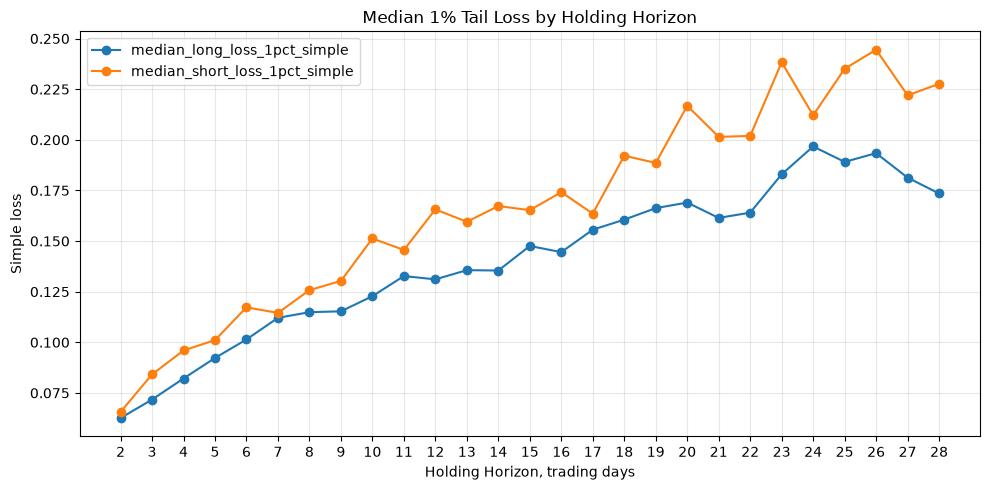

In [83]:
# Cell 45
# 图 1：全市场多头 / 空头 1% 尾部亏损随 horizon 的变化

tail_horizon_summary = (
    risk_multiplier_df
    .groupby("horizon_days")
    .agg(
        median_long_loss_1pct_simple=("long_loss_1pct_simple", "median"),
        median_short_loss_1pct_simple=("short_loss_1pct_simple", "median"),
        median_conservative_multiplier=("conservative_risk_multiplier", "median"),
    )
    .reset_index()
    .sort_values("horizon_days")
)

display(tail_horizon_summary)

safe_line_plot(
    df=tail_horizon_summary,
    x_col="horizon_days",
    y_cols=["median_long_loss_1pct_simple", "median_short_loss_1pct_simple"],
    title="Median 1% Tail Loss by Holding Horizon",
    xlabel="Holding Horizon, trading days",
    ylabel="Simple loss",
    xticks=HORIZON_DAYS,
)

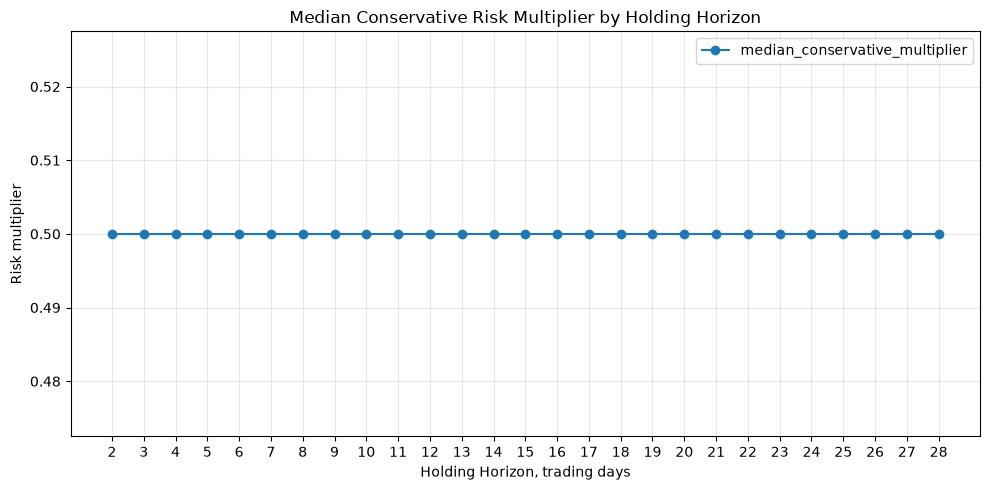

In [84]:
# Cell 46
# 图 2：仓位折扣系数随 horizon 的变化

safe_line_plot(
    df=tail_horizon_summary,
    x_col="horizon_days",
    y_cols=["median_conservative_multiplier"],
    title="Median Conservative Risk Multiplier by Holding Horizon",
    xlabel="Holding Horizon, trading days",
    ylabel="Risk multiplier",
    xticks=HORIZON_DAYS,
)

bucket_en
Short-term      2
Short-swing     3
Swing           7
Mid-term        5
Monthly        10
Name: count, dtype: int64

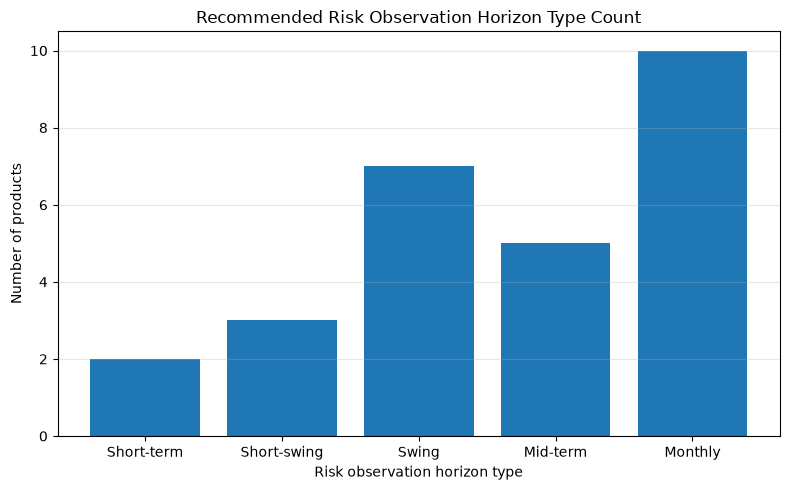

In [94]:
# Cell 50

import matplotlib.pyplot as plt
import logging

# Suppress matplotlib font warning
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# Use default English font to avoid Chinese font issues
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# Keep original DataFrame name
plot_df = product_trade_type_recommendation_df.copy()

# Chinese bucket labels -> English labels
bucket_label_map = {
    "短线": "Short-term",
    "短波段": "Short-swing",
    "波段": "Swing",
    "中周期": "Mid-term",
    "其他": "Monthly",
    "月度": "Monthly",
    "月度观察": "Monthly",
}

bucket_order_cn = ["短线", "短波段", "波段", "中周期", "其他", "月度", "月度观察"]
bucket_order_en = ["Short-term", "Short-swing", "Swing", "Mid-term", "Monthly"]

# Map bucket labels
plot_df["bucket_en"] = plot_df["bucket"].map(bucket_label_map).fillna(plot_df["bucket"])

# If the table contains both long / short rows, avoid double counting products
if {"品种", "direction"}.issubset(plot_df.columns):
    plot_df = plot_df.drop_duplicates(subset=["品种"], keep="first")

# Count products by recommended risk observation horizon
trade_type_counts = (
    plot_df["bucket_en"]
    .value_counts()
    .reindex(bucket_order_en)
    .fillna(0)
    .astype(int)
)

display(trade_type_counts)

plt.figure(figsize=(8, 5))
plt.bar(trade_type_counts.index, trade_type_counts.values)

plt.title("Recommended Risk Observation Horizon Type Count")
plt.xlabel("Risk observation horizon type")
plt.ylabel("Number of products")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

,state_dimension,state_value,horizon_days,contracts,median_state_n,median_long_loss_1pct_simple,median_short_loss_1pct_simple,avg_long_loss_1pct_simple,avg_short_loss_1pct_simple,median_tail_asymmetry
54,波动状态,high_vol,2,27,415.0,0.074628,0.066600,0.076463,0.076291,0.920668
55,波动状态,high_vol,3,27,278.0,0.084671,0.093584,0.091609,0.094761,0.946357
56,波动状态,high_vol,4,27,208.0,0.096854,0.098408,0.096480,0.107487,0.898114
57,波动状态,high_vol,5,27,165.0,0.100995,0.109182,0.106532,0.117198,0.998921
58,波动状态,high_vol,6,27,139.0,0.109168,0.120885,0.119894,0.125653,0.950307
59,波动状态,high_vol,7,27,118.0,0.121546,0.116680,0.122586,0.142044,0.965578
60,波动状态,high_vol,8,27,104.0,0.121358,0.126666,0.130731,0.139664,0.825272
61,波动状态,high_vol,9,27,94.0,0.115121,0.133381,0.124731,0.146090,0.938435
62,波动状态,high_vol,10,27,82.0,0.135537,0.164539,0.139923,0.159814,0.991001
63,波动状态,high_vol,11,26,76.0,0.143724,0.144680,0.143237,0.145123,0.899746


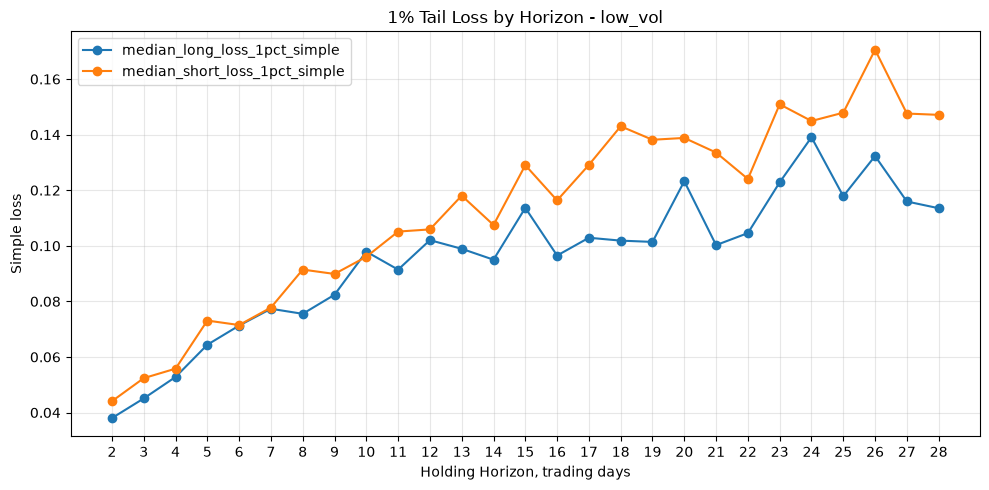

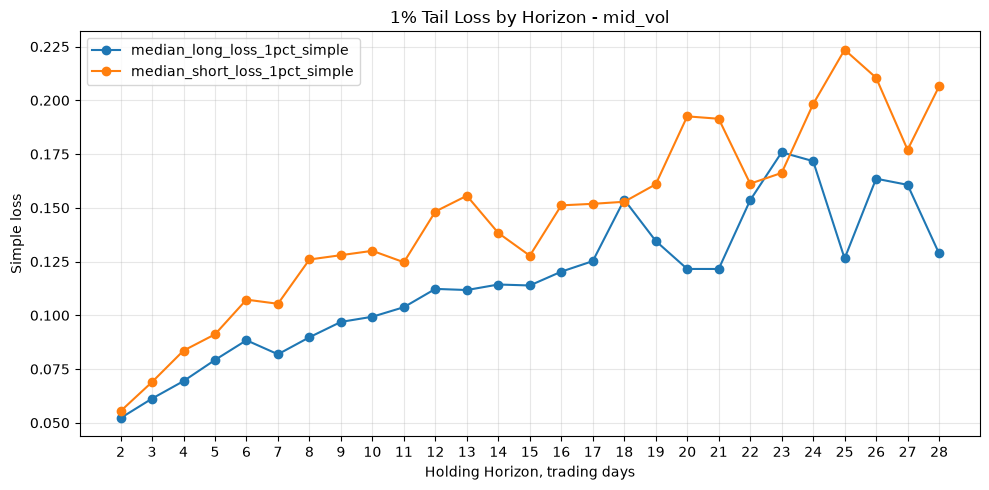

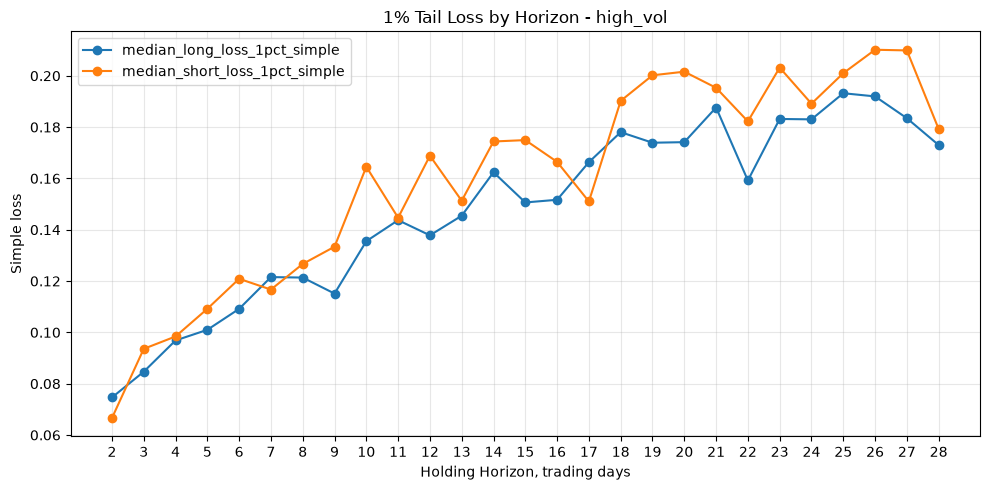

In [96]:
# Cell 52
# 输出 Excel：交易化模块完整结果

with pd.ExcelWriter(TRADING_OUTPUT_EXCEL, engine="openpyxl") as writer:
    pd.DataFrame([asdict(CFG)]).to_excel(writer, sheet_name="config", index=False)

    # 原始交易面板与状态
    horizon_trade_panel_df.to_excel(writer, sheet_name="trade_panel", index=False)
    quality_df.to_excel(writer, sheet_name="price_quality", index=False)

    # 1. 尾部分位数
    tail_risk_df.to_excel(writer, sheet_name="tail_quantiles", index=False)

    # 2. 仓位折扣
    risk_multiplier_df.to_excel(writer, sheet_name="risk_multiplier", index=False)

    # 3. 多空方向分开
    directional_risk_df.to_excel(writer, sheet_name="directional_risk", index=False)

    # 4. 交易周期分类
    bucket_trade_type_df.to_excel(writer, sheet_name="bucket_type_score", index=False)
    product_trade_type_recommendation_df.to_excel(writer, sheet_name="product_type_rec", index=False)
    direction_bucket_df.to_excel(writer, sheet_name="direction_type_score", index=False)
    direction_trade_type_recommendation_df.to_excel(writer, sheet_name="direction_type_rec", index=False)

    # 5. 状态分层
    state_tail_df.to_excel(writer, sheet_name="state_tail", index=False)
    state_market_summary_df.to_excel(writer, sheet_name="state_market_summary", index=False)
    rollover_pivot.to_excel(writer, sheet_name="rollover_proxy_compare", index=False)

    # 汇总图表用表
    tail_horizon_summary.to_excel(writer, sheet_name="horizon_tail_summary", index=False)

print(f"已输出：{TRADING_OUTPUT_EXCEL}")

已输出：tq_horizon_2D_25D_gaussian_test_trading_module.xlsx


In [103]:
# Cell 55
# Sample-Aware Non-Gaussian Futures Risk Overlay
# 配置区
#
# 直接接在当前项目后面运行。
# 前置变量要求：
# price_data
# CONTRACTS
# CFG

import os
import math
import json
from dataclasses import dataclass, asdict
from datetime import datetime

import numpy as np
import pandas as pd
from scipy import stats


REQUIRED_GLOBALS = ["price_data", "CONTRACTS", "CFG"]
missing_globals = [x for x in REQUIRED_GLOBALS if x not in globals()]

if missing_globals:
    raise RuntimeError(f"缺少前置变量，请先运行前面的主流程：{missing_globals}")


@dataclass
class SampleAwareRiskOverlayConfig:
    # 核心 horizon
    horizons: tuple = (1, 2, 5, 10, 16, 21, 28)

    # 必须使用 nonoverlap 作为正式 position limit 口径
    horizon_method: str = "nonoverlap"

    # 账户参数
    account_equity: float = 1_000_000.0
    risk_budget_pct_list: tuple = (0.0025, 0.005, 0.01)

    # 样本量规则阈值
    high_sample_threshold: int = 500
    medium_sample_threshold: int = 200
    low_1pct_unstable_threshold: int = 100
    low_sample_threshold: int = 50

    # 输出目录
    output_root: str = "sample_aware_non_gaussian_risk_overlay_output"
    timestamp: str = datetime.now().strftime("%Y%m%d_%H%M%S")


SA_CFG = SampleAwareRiskOverlayConfig()

SA_OUTPUT_DIR = os.path.join(
    SA_CFG.output_root,
    f"run_{SA_CFG.timestamp}"
)

os.makedirs(SA_OUTPUT_DIR, exist_ok=True)

print("Sample-Aware Risk Overlay config:")
print(asdict(SA_CFG))
print("Output dir:", SA_OUTPUT_DIR)

Sample-Aware Risk Overlay config:
{'horizons': (1, 2, 5, 10, 16, 21, 28), 'horizon_method': 'nonoverlap', 'account_equity': 1000000.0, 'risk_budget_pct_list': (0.0025, 0.005, 0.01), 'high_sample_threshold': 500, 'medium_sample_threshold': 200, 'low_1pct_unstable_threshold': 100, 'low_sample_threshold': 50, 'output_root': 'sample_aware_non_gaussian_risk_overlay_output', 'timestamp': '20260617_191933'}
Output dir: sample_aware_non_gaussian_risk_overlay_output/run_20260617_191933


In [105]:
# Cell 56
# 合约乘数配置
#
# multiplier 用于：
# 一手尾部亏损金额 = latest_price × multiplier × primary_tail_metric
#
# 如你有更权威的交易所合约参数表，可以直接替换这里。

CONTRACT_MULTIPLIER_BY_NAME = {
    # 贵金属 / 有色
    "沪金": 1000,
    "沪银": 15,
    "沪铜": 5,
    "沪铝": 5,
    "沪锡": 1,
    "氧化铝": 20,

    # 黑色
    "铁矿石": 100,
    "焦煤": 60,
    "热轧板": 10,
    "螺纹钢": 10,

    # 能源 / 化工
    "原油": 1000,
    "橡胶": 10,
    "PTA": 5,
    "甲醇": 10,
    "PVC": 5,
    "纯碱": 20,
    "玻璃": 20,
    "烧碱": 30,

    # 农产品 / 油脂油料
    "豆粕": 10,
    "豆油": 10,
    "棕榈油": 10,
    "菜油": 10,
    "棉花": 5,
    "白糖": 10,
    "鸡蛋": 10,
    "生猪": 16,

    # 新能源
    "碳酸锂": 1,
}

CONTRACT_MULTIPLIER_BY_SYMBOL = {
    CONTRACTS[name]: multiplier
    for name, multiplier in CONTRACT_MULTIPLIER_BY_NAME.items()
    if name in CONTRACTS
}

contract_parameter_df = pd.DataFrame([
    {
        "品种": name,
        "symbol": CONTRACTS.get(name, None),
        "multiplier": multiplier,
    }
    for name, multiplier in CONTRACT_MULTIPLIER_BY_NAME.items()
])

display(contract_parameter_df)

,品种,symbol,multiplier
0,沪金,KQ.m@SHFE.au,1000
1,沪银,KQ.m@SHFE.ag,15
2,沪铜,KQ.m@SHFE.cu,5
3,沪铝,KQ.m@SHFE.al,5
4,沪锡,KQ.m@SHFE.sn,1
5,氧化铝,KQ.m@SHFE.ao,20
6,铁矿石,KQ.m@DCE.i,100
7,焦煤,KQ.m@DCE.jm,60
8,热轧板,KQ.m@SHFE.hc,10
9,螺纹钢,KQ.m@SHFE.rb,10


In [107]:
# Cell 57
# 工具函数

def reason_join(reasons) -> str:
    reasons = [str(r) for r in reasons if r]
    return "; ".join(reasons) if reasons else ""


def resolve_product_name(symbol_or_name: str) -> str:
    """
    支持输入：
    - 中文品种名：铁矿石
    - TqSdk 主连 symbol：KQ.m@DCE.i
    """
    if symbol_or_name in price_data:
        return symbol_or_name

    for name, sym in CONTRACTS.items():
        if symbol_or_name == sym:
            return name

    raise KeyError(f"无法识别 symbol_or_name={symbol_or_name}")


def resolve_direction(direction: str) -> str:
    d = str(direction).lower().strip()

    long_alias = {"long", "buy", "多", "做多", "多头"}
    short_alias = {"short", "sell", "空", "做空", "空头"}

    if d in long_alias:
        return "long"

    if d in short_alias:
        return "short"

    raise ValueError(f"direction 只能是 long/short/做多/做空，当前={direction}")


def map_to_nearest_higher_horizon(days: int, horizons) -> tuple:
    """
    将 current_holding_days 映射到最近的更高 horizon。
    若超过最大 horizon，则使用最大 horizon，并标记原因。
    """
    days = int(days)
    horizons = sorted([int(x) for x in horizons])

    for h in horizons:
        if days <= h:
            return h, "mapped_to_nearest_higher"

    return horizons[-1], "exceed_max_horizon_use_max"


def get_latest_price(name: str) -> float:
    df = price_data[name].copy()
    df = df.dropna(subset=["close"])
    df = df[df["close"] > 0]

    if df.empty:
        return np.nan

    return float(df.sort_values("date")["close"].iloc[-1])


def get_multiplier(name: str) -> float:
    if name in CONTRACT_MULTIPLIER_BY_NAME:
        return float(CONTRACT_MULTIPLIER_BY_NAME[name])

    symbol = CONTRACTS.get(name, None)

    if symbol in CONTRACT_MULTIPLIER_BY_SYMBOL:
        return float(CONTRACT_MULTIPLIER_BY_SYMBOL[symbol])

    return np.nan


def simple_loss_from_log_loss(log_loss: float) -> float:
    """
    log loss 转简单亏损比例。
    例如 log loss = 0.10，对多头左尾表示价格下跌约 1-exp(-0.10)。
    对空头右尾如果使用 log gain，简单亏损约 exp(0.10)-1。
    这里 position sizing 使用名义金额 × log_loss，保持和前面项目一致。
    该函数主要用于展示。
    """
    if pd.isna(log_loss):
        return np.nan
    return float(np.exp(float(log_loss)) - 1)

In [108]:
# Cell 58
# 构造 nonoverlap horizon return
#
# 注意：
# 正式仓位上限必须使用 nonoverlap sample_size 判断可靠性。
# 因此这里强制使用 SA_CFG.horizon_method，默认 nonoverlap。

def make_horizon_returns_from_price_df(
    df: pd.DataFrame,
    horizon: int,
    method: str = "nonoverlap",
) -> pd.Series:
    """
    return_h = log(close_t+h / close_t)
    """
    x = df[["date", "close"]].dropna().copy()
    x = x.sort_values("date")
    x = x[x["close"] > 0].reset_index(drop=True)

    if len(x) <= horizon:
        return pd.Series(dtype=float, name=f"{horizon}D_return")

    prices = x["close"].astype(float)
    dates = pd.to_datetime(x["date"])

    if method == "nonoverlap":
        idx = np.arange(0, len(x), horizon)

        if len(idx) < 2:
            return pd.Series(dtype=float, name=f"{horizon}D_return")

        p = prices.iloc[idx].reset_index(drop=True)
        d = dates.iloc[idx].reset_index(drop=True)

        r = np.log(p / p.shift(1))
        r.index = d

    elif method == "overlap":
        r = np.log(prices / prices.shift(horizon))
        r.index = dates

    else:
        raise ValueError("method must be nonoverlap or overlap")

    r = r.replace([np.inf, -np.inf], np.nan).dropna()
    r.name = f"{horizon}D_return"

    return r


sample_aware_returns_data = {}
sample_aware_sample_rows = []

for name, df in price_data.items():
    for horizon in SA_CFG.horizons:
        r = make_horizon_returns_from_price_df(
            df=df,
            horizon=int(horizon),
            method=SA_CFG.horizon_method,
        )

        sample_aware_returns_data[(name, int(horizon))] = r

        sample_aware_sample_rows.append({
            "symbol": CONTRACTS.get(name),
            "品种": name,
            "horizon": int(horizon),
            "method": SA_CFG.horizon_method,
            "sample_size": len(r),
            "tail_obs_1pct": len(r) * 0.01,
            "tail_obs_5pct": len(r) * 0.05,
            "start": r.index.min() if len(r) > 0 else pd.NaT,
            "end": r.index.max() if len(r) > 0 else pd.NaT,
        })

sample_aware_sample_size_df = pd.DataFrame(sample_aware_sample_rows)

display(sample_aware_sample_size_df)

,symbol,品种,horizon,method,sample_size,tail_obs_1pct,tail_obs_5pct,start,end
0,KQ.m@SHFE.au,沪金,1,nonoverlap,2537,25.37,126.85,2016-01-05,2026-06-17
1,KQ.m@SHFE.au,沪金,2,nonoverlap,1268,12.68,63.40,2016-01-06,2026-06-16
2,KQ.m@SHFE.au,沪金,5,nonoverlap,507,5.07,25.35,2016-01-11,2026-06-15
3,KQ.m@SHFE.au,沪金,10,nonoverlap,253,2.53,12.65,2016-01-18,2026-06-08
4,KQ.m@SHFE.au,沪金,16,nonoverlap,158,1.58,7.90,2016-01-26,2026-06-04
5,KQ.m@SHFE.au,沪金,21,nonoverlap,120,1.20,6.00,2016-02-02,2026-05-25
6,KQ.m@SHFE.au,沪金,28,nonoverlap,90,0.90,4.50,2016-02-18,2026-05-25
7,KQ.m@SHFE.ag,沪银,1,nonoverlap,2537,25.37,126.85,2016-01-05,2026-06-17
8,KQ.m@SHFE.ag,沪银,2,nonoverlap,1268,12.68,63.40,2016-01-06,2026-06-16
9,KQ.m@SHFE.ag,沪银,5,nonoverlap,507,5.07,25.35,2016-01-11,2026-06-15


In [109]:
# Cell 59
# 样本量感知尾部指标计算
#
# 输出字段：
# symbol, 品种, horizon, direction, sample_size,
# empirical_5pct_loss,
# empirical_1pct_loss,
# expected_shortfall_5pct,
# expected_shortfall_1pct,
# max_observed_loss,
# primary_tail_metric,
# reliability_flag,
# reason

def compute_directional_tail_metrics_from_returns(
    name: str,
    horizon: int,
    r: pd.Series,
    direction: str,
) -> dict:
    direction = resolve_direction(direction)

    reasons = []

    x = pd.Series(r).dropna().astype(float)
    x = x.replace([np.inf, -np.inf], np.nan).dropna()

    sample_size = len(x)
    tail_obs_1pct = sample_size * 0.01
    tail_obs_5pct = sample_size * 0.05

    if sample_size == 0:
        return {
            "symbol": CONTRACTS.get(name),
            "品种": name,
            "horizon": int(horizon),
            "direction": direction,

            "sample_size": sample_size,
            "tail_obs_1pct": tail_obs_1pct,
            "tail_obs_5pct": tail_obs_5pct,

            "empirical_5pct_loss": np.nan,
            "empirical_1pct_loss": np.nan,
            "expected_shortfall_5pct": np.nan,
            "expected_shortfall_1pct": np.nan,
            "max_observed_loss": np.nan,

            "primary_tail_metric": np.nan,
            "reliability_flag": "INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT",
            "reason": "EMPTY_RETURN_SERIES",
        }

    if direction == "long":
        q05 = float(x.quantile(0.05))
        q01 = float(x.quantile(0.01))

        empirical_5pct_loss = max(0.0, -q05)
        empirical_1pct_loss = max(0.0, -q01)

        es5_sample = x[x <= q05]
        es1_sample = x[x <= q01]

        expected_shortfall_5pct = max(0.0, -float(es5_sample.mean())) if len(es5_sample) > 0 else np.nan
        expected_shortfall_1pct = max(0.0, -float(es1_sample.mean())) if len(es1_sample) > 0 else np.nan

        max_observed_loss = max(0.0, -float(x.min()))

    else:
        q95 = float(x.quantile(0.95))
        q99 = float(x.quantile(0.99))

        empirical_5pct_loss = max(0.0, q95)
        empirical_1pct_loss = max(0.0, q99)

        es5_sample = x[x >= q95]
        es1_sample = x[x >= q99]

        expected_shortfall_5pct = max(0.0, float(es5_sample.mean())) if len(es5_sample) > 0 else np.nan
        expected_shortfall_1pct = max(0.0, float(es1_sample.mean())) if len(es1_sample) > 0 else np.nan

        max_observed_loss = max(0.0, float(x.max()))

    # 样本量感知主尾部指标
    if sample_size >= SA_CFG.high_sample_threshold:
        primary_tail_metric = empirical_1pct_loss
        reliability_flag = "HIGH"

    elif sample_size >= SA_CFG.medium_sample_threshold:
        primary_tail_metric = np.nanmax([empirical_1pct_loss, expected_shortfall_5pct])
        reliability_flag = "MEDIUM"

    elif sample_size >= SA_CFG.low_1pct_unstable_threshold:
        primary_tail_metric = np.nanmax([empirical_5pct_loss, expected_shortfall_5pct])
        reliability_flag = "LOW_1PCT_UNSTABLE"
        reasons.append("EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY")

    elif sample_size >= SA_CFG.low_sample_threshold:
        primary_tail_metric = np.nanmax([empirical_5pct_loss, max_observed_loss * 0.5])
        reliability_flag = "LOW_SAMPLE"
        reasons.append("EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY")
        reasons.append("POSITION_LIMIT_BASED_ON_5PCT_AND_HALF_MAX_LOSS")

    else:
        primary_tail_metric = np.nan
        reliability_flag = "INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT"
        reasons.append("NO_FORMAL_POSITION_LIMIT")
        reasons.append("ONLY_MAX_OBSERVED_AND_5PCT_FOR_REFERENCE")

    if pd.isna(primary_tail_metric):
        reasons.append("PRIMARY_TAIL_METRIC_MISSING")

    if pd.notna(primary_tail_metric) and primary_tail_metric <= 0:
        reasons.append("PRIMARY_TAIL_METRIC_ZERO")

    return {
        "symbol": CONTRACTS.get(name),
        "品种": name,
        "horizon": int(horizon),
        "direction": direction,

        "sample_size": sample_size,
        "tail_obs_1pct": tail_obs_1pct,
        "tail_obs_5pct": tail_obs_5pct,

        "empirical_5pct_loss": empirical_5pct_loss,
        "empirical_1pct_loss": empirical_1pct_loss,
        "expected_shortfall_5pct": expected_shortfall_5pct,
        "expected_shortfall_1pct": expected_shortfall_1pct,
        "max_observed_loss": max_observed_loss,

        "primary_tail_metric": primary_tail_metric,
        "reliability_flag": reliability_flag,
        "reason": reason_join(reasons),
    }


sample_aware_tail_rows = []

for (name, horizon), r in sample_aware_returns_data.items():
    for direction in ["long", "short"]:
        sample_aware_tail_rows.append(
            compute_directional_tail_metrics_from_returns(
                name=name,
                horizon=horizon,
                r=r,
                direction=direction,
            )
        )

sample_aware_tail_risk_table = pd.DataFrame(sample_aware_tail_rows)

sample_aware_tail_risk_table = sample_aware_tail_risk_table.sort_values(
    ["品种", "horizon", "direction"]
).reset_index(drop=True)

display(sample_aware_tail_risk_table)

,symbol,品种,horizon,direction,sample_size,tail_obs_1pct,tail_obs_5pct,empirical_5pct_loss,empirical_1pct_loss,expected_shortfall_5pct,expected_shortfall_1pct,max_observed_loss,primary_tail_metric,reliability_flag,reason
0,KQ.m@CZCE.TA,PTA,1,long,2537,25.37,126.85,0.025451,0.045644,0.037890,0.057396,0.084019,0.045644,HIGH,
1,KQ.m@CZCE.TA,PTA,1,short,2537,25.37,126.85,0.026587,0.044261,0.037702,0.057642,0.074153,0.044261,HIGH,
2,KQ.m@CZCE.TA,PTA,2,long,1268,12.68,63.40,0.035319,0.064229,0.051773,0.078749,0.101704,0.064229,HIGH,
3,KQ.m@CZCE.TA,PTA,2,short,1268,12.68,63.40,0.036804,0.060643,0.050002,0.068350,0.094452,0.060643,HIGH,
4,KQ.m@CZCE.TA,PTA,5,long,507,5.07,25.35,0.055781,0.091905,0.072647,0.099163,0.107154,0.091905,HIGH,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,KQ.m@DCE.jd,鸡蛋,16,short,158,1.58,7.90,0.133237,0.214732,0.196960,0.219619,0.223920,0.196960,LOW_1PCT_UNSTABLE,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY
374,KQ.m@DCE.jd,鸡蛋,21,long,120,1.20,6.00,0.130079,0.184112,0.174789,0.185822,0.186641,0.174789,LOW_1PCT_UNSTABLE,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY
375,KQ.m@DCE.jd,鸡蛋,21,short,120,1.20,6.00,0.140589,0.208740,0.195595,0.215567,0.219397,0.195595,LOW_1PCT_UNSTABLE,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY
376,KQ.m@DCE.jd,鸡蛋,28,long,90,0.90,4.50,0.138266,0.221515,0.202658,0.266791,0.266791,0.138266,LOW_SAMPLE,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY; POS...


In [110]:
# Cell 60
# Position Limit Table
#
# 所有正式仓位上限只能使用 primary_tail_metric。
# empirical_1pct_loss 只能作为字段展示，不能作为 max_lots 依据。

def compute_sample_aware_position_limit_rows(row: pd.Series) -> list:
    name = row["品种"]
    symbol = row["symbol"]
    horizon = int(row["horizon"])
    direction = row["direction"]

    latest_price = get_latest_price(name)
    multiplier = get_multiplier(name)

    primary_tail_metric = row["primary_tail_metric"]
    reliability_flag = row["reliability_flag"]

    reasons_base = []

    if pd.isna(latest_price) or latest_price <= 0:
        reasons_base.append("LATEST_PRICE_MISSING_OR_INVALID")

    if pd.isna(multiplier) or multiplier <= 0:
        reasons_base.append("MULTIPLIER_MISSING_OR_INVALID")

    if pd.isna(primary_tail_metric):
        reasons_base.append("PRIMARY_TAIL_METRIC_MISSING")

    if pd.notna(primary_tail_metric) and primary_tail_metric <= 0:
        reasons_base.append("PRIMARY_TAIL_METRIC_ZERO")

    if reliability_flag == "INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT":
        reasons_base.append("INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT")

    if (
        pd.notna(latest_price)
        and latest_price > 0
        and pd.notna(multiplier)
        and multiplier > 0
        and pd.notna(primary_tail_metric)
        and primary_tail_metric > 0
        and reliability_flag != "INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT"
    ):
        one_lot_tail_loss_amount = latest_price * multiplier * primary_tail_metric
    else:
        one_lot_tail_loss_amount = np.nan

    rows = []

    for risk_budget_pct in SA_CFG.risk_budget_pct_list:
        risk_budget_amount = SA_CFG.account_equity * risk_budget_pct
        reasons = list(reasons_base)

        if pd.isna(one_lot_tail_loss_amount) or one_lot_tail_loss_amount <= 0:
            max_lots = np.nan
            reasons.append("NO_FORMAL_POSITION_LIMIT")
        else:
            max_lots = math.floor(risk_budget_amount / one_lot_tail_loss_amount)
            max_lots = max(0, max_lots)

        status = "OK" if not reasons else "CHECK"

        rows.append({
            "symbol": symbol,
            "品种": name,
            "horizon": horizon,
            "direction": direction,

            "latest_price": latest_price,
            "multiplier": multiplier,

            "sample_size": row["sample_size"],
            "tail_obs_1pct": row["tail_obs_1pct"],
            "tail_obs_5pct": row["tail_obs_5pct"],

            "empirical_5pct_loss": row["empirical_5pct_loss"],
            "empirical_1pct_loss": row["empirical_1pct_loss"],
            "expected_shortfall_5pct": row["expected_shortfall_5pct"],
            "expected_shortfall_1pct": row["expected_shortfall_1pct"],
            "max_observed_loss": row["max_observed_loss"],

            "primary_tail_metric": primary_tail_metric,
            "reliability_flag": reliability_flag,

            "one_lot_tail_loss_amount": one_lot_tail_loss_amount,

            "account_equity": SA_CFG.account_equity,
            "risk_budget_pct": risk_budget_pct,
            "risk_budget_amount": risk_budget_amount,

            "max_lots": max_lots,

            "status": status,
            "reason": reason_join([row.get("reason", ""), *reasons]),
        })

    return rows


sample_aware_position_limit_rows = []

for _, row in sample_aware_tail_risk_table.iterrows():
    sample_aware_position_limit_rows.extend(
        compute_sample_aware_position_limit_rows(row)
    )

sample_aware_position_limit_table = pd.DataFrame(sample_aware_position_limit_rows)

sample_aware_position_limit_table = sample_aware_position_limit_table.sort_values(
    ["品种", "horizon", "direction", "risk_budget_pct"]
).reset_index(drop=True)

display(sample_aware_position_limit_table)

,symbol,品种,horizon,direction,latest_price,multiplier,sample_size,tail_obs_1pct,tail_obs_5pct,empirical_5pct_loss,empirical_1pct_loss,expected_shortfall_5pct,expected_shortfall_1pct,max_observed_loss,primary_tail_metric,reliability_flag,one_lot_tail_loss_amount,account_equity,risk_budget_pct,risk_budget_amount,max_lots,status,reason
0,KQ.m@CZCE.TA,PTA,1,long,5860.0,5.0,2537,25.37,126.85,0.025451,0.045644,0.037890,0.057396,0.084019,0.045644,HIGH,1337.370780,1000000.0,0.0025,2500.0,1.0,OK,
1,KQ.m@CZCE.TA,PTA,1,long,5860.0,5.0,2537,25.37,126.85,0.025451,0.045644,0.037890,0.057396,0.084019,0.045644,HIGH,1337.370780,1000000.0,0.0050,5000.0,3.0,OK,
2,KQ.m@CZCE.TA,PTA,1,long,5860.0,5.0,2537,25.37,126.85,0.025451,0.045644,0.037890,0.057396,0.084019,0.045644,HIGH,1337.370780,1000000.0,0.0100,10000.0,7.0,OK,
3,KQ.m@CZCE.TA,PTA,1,short,5860.0,5.0,2537,25.37,126.85,0.026587,0.044261,0.037702,0.057642,0.074153,0.044261,HIGH,1296.856148,1000000.0,0.0025,2500.0,1.0,OK,
4,KQ.m@CZCE.TA,PTA,1,short,5860.0,5.0,2537,25.37,126.85,0.026587,0.044261,0.037702,0.057642,0.074153,0.044261,HIGH,1296.856148,1000000.0,0.0050,5000.0,3.0,OK,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1129,KQ.m@DCE.jd,鸡蛋,28,long,4678.0,10.0,90,0.90,4.50,0.138266,0.221515,0.202658,0.266791,0.266791,0.138266,LOW_SAMPLE,6468.104225,1000000.0,0.0050,5000.0,0.0,OK,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY; POS...
1130,KQ.m@DCE.jd,鸡蛋,28,long,4678.0,10.0,90,0.90,4.50,0.138266,0.221515,0.202658,0.266791,0.266791,0.138266,LOW_SAMPLE,6468.104225,1000000.0,0.0100,10000.0,1.0,OK,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY; POS...
1131,KQ.m@DCE.jd,鸡蛋,28,short,4678.0,10.0,90,0.90,4.50,0.182922,0.248335,0.236330,0.346477,0.346477,0.182922,LOW_SAMPLE,8557.107571,1000000.0,0.0025,2500.0,0.0,OK,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY; POS...
1132,KQ.m@DCE.jd,鸡蛋,28,short,4678.0,10.0,90,0.90,4.50,0.182922,0.248335,0.236330,0.346477,0.346477,0.182922,LOW_SAMPLE,8557.107571,1000000.0,0.0050,5000.0,0.0,OK,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY; POS...


In [111]:
# Cell 61
# Trade Admission
#
# 所有准入检查只能使用 primary_tail_metric 对应的 one_lot_tail_loss_amount。

def lookup_sample_aware_position_limit(
    symbol_or_name: str,
    direction: str,
    horizon: int,
    account_equity: float,
    risk_budget_pct: float,
) -> dict:
    name = resolve_product_name(symbol_or_name)
    direction = resolve_direction(direction)
    horizon = int(horizon)

    base = sample_aware_position_limit_table[
        (sample_aware_position_limit_table["品种"] == name)
        & (sample_aware_position_limit_table["direction"] == direction)
        & (sample_aware_position_limit_table["horizon"] == horizon)
        & (np.isclose(sample_aware_position_limit_table["risk_budget_pct"], risk_budget_pct))
    ].copy()

    if base.empty:
        base_any = sample_aware_position_limit_table[
            (sample_aware_position_limit_table["品种"] == name)
            & (sample_aware_position_limit_table["direction"] == direction)
            & (sample_aware_position_limit_table["horizon"] == horizon)
        ].copy()

        if base_any.empty:
            return {
                "found": False,
                "reason": "NO_POSITION_LIMIT_ROW",
            }

        row = base_any.iloc[0].to_dict()
    else:
        row = base.iloc[0].to_dict()

    one_lot_tail_loss_amount = row.get("one_lot_tail_loss_amount", np.nan)
    primary_tail_metric = row.get("primary_tail_metric", np.nan)
    reliability_flag = row.get("reliability_flag", "")

    risk_budget_amount = account_equity * risk_budget_pct

    reasons = [row.get("reason", "")]

    if reliability_flag == "INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT":
        suggested_max_lots = np.nan
        reasons.append("INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT")
    elif pd.isna(one_lot_tail_loss_amount) or one_lot_tail_loss_amount <= 0:
        suggested_max_lots = np.nan
        reasons.append("ONE_LOT_TAIL_LOSS_AMOUNT_INVALID")
    else:
        suggested_max_lots = math.floor(risk_budget_amount / one_lot_tail_loss_amount)
        suggested_max_lots = max(0, suggested_max_lots)

    return {
        "found": True,
        "symbol": CONTRACTS.get(name),
        "品种": name,
        "direction": direction,
        "horizon": horizon,

        "sample_size": row.get("sample_size", np.nan),
        "tail_obs_1pct": row.get("tail_obs_1pct", np.nan),
        "tail_obs_5pct": row.get("tail_obs_5pct", np.nan),

        "empirical_5pct_loss": row.get("empirical_5pct_loss", np.nan),
        "empirical_1pct_loss": row.get("empirical_1pct_loss", np.nan),
        "expected_shortfall_5pct": row.get("expected_shortfall_5pct", np.nan),
        "expected_shortfall_1pct": row.get("expected_shortfall_1pct", np.nan),
        "max_observed_loss": row.get("max_observed_loss", np.nan),

        "primary_tail_metric": primary_tail_metric,
        "reliability_flag": reliability_flag,

        "latest_price": row.get("latest_price", np.nan),
        "multiplier": row.get("multiplier", np.nan),
        "one_lot_tail_loss_amount": one_lot_tail_loss_amount,

        "account_equity": account_equity,
        "risk_budget_pct": risk_budget_pct,
        "risk_budget_amount": risk_budget_amount,
        "suggested_max_lots": suggested_max_lots,

        "reason": reason_join(reasons),
    }


def check_trade(
    symbol,
    direction,
    horizon,
    lots,
    account_equity=None,
    risk_budget_pct=0.01,
):
    """
    Sample-aware 交易准入检查。

    status:
    PASS
    REDUCE
    REJECT
    INVALID
    """
    if account_equity is None:
        account_equity = SA_CFG.account_equity

    direction = resolve_direction(direction)
    lots = int(lots)

    info = lookup_sample_aware_position_limit(
        symbol_or_name=symbol,
        direction=direction,
        horizon=int(horizon),
        account_equity=float(account_equity),
        risk_budget_pct=float(risk_budget_pct),
    )

    if not info.get("found", False):
        return pd.DataFrame([{
            "symbol": symbol,
            "direction": direction,
            "horizon": horizon,
            "lots": lots,

            "primary_tail_metric": np.nan,
            "reliability_flag": "UNKNOWN",
            "one_lot_tail_loss_amount": np.nan,
            "total_tail_loss_amount": np.nan,
            "risk_budget_amount": account_equity * risk_budget_pct,

            "status": "INVALID",
            "suggested_max_lots": np.nan,
            "reason": info.get("reason", "UNKNOWN"),
        }])

    one_lot_tail_loss_amount = info["one_lot_tail_loss_amount"]
    risk_budget_amount = info["risk_budget_amount"]
    suggested_max_lots = info["suggested_max_lots"]
    reliability_flag = info["reliability_flag"]

    reasons = [info.get("reason", "")]

    if reliability_flag == "INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT":
        total_tail_loss_amount = np.nan
        status = "INVALID"
        reasons.append("NO_FORMAL_POSITION_LIMIT")

    elif pd.isna(one_lot_tail_loss_amount) or one_lot_tail_loss_amount <= 0:
        total_tail_loss_amount = np.nan
        status = "INVALID"
        reasons.append("ONE_LOT_TAIL_LOSS_AMOUNT_INVALID")

    else:
        total_tail_loss_amount = lots * one_lot_tail_loss_amount

        if total_tail_loss_amount <= risk_budget_amount:
            status = "PASS"
        elif pd.notna(suggested_max_lots) and suggested_max_lots >= 1:
            status = "REDUCE"
        else:
            status = "REJECT"

    return pd.DataFrame([{
        "symbol": info["symbol"],
        "品种": info["品种"],
        "direction": direction,
        "horizon": int(horizon),
        "lots": lots,

        "sample_size": info["sample_size"],
        "tail_obs_1pct": info["tail_obs_1pct"],
        "tail_obs_5pct": info["tail_obs_5pct"],

        "empirical_5pct_loss": info["empirical_5pct_loss"],
        "empirical_1pct_loss": info["empirical_1pct_loss"],
        "expected_shortfall_5pct": info["expected_shortfall_5pct"],
        "expected_shortfall_1pct": info["expected_shortfall_1pct"],
        "max_observed_loss": info["max_observed_loss"],

        "primary_tail_metric": info["primary_tail_metric"],
        "reliability_flag": reliability_flag,

        "latest_price": info["latest_price"],
        "multiplier": info["multiplier"],

        "one_lot_tail_loss_amount": one_lot_tail_loss_amount,
        "total_tail_loss_amount": total_tail_loss_amount,

        "account_equity": account_equity,
        "risk_budget_pct": risk_budget_pct,
        "risk_budget_amount": risk_budget_amount,

        "status": status,
        "suggested_max_lots": suggested_max_lots,
        "reason": reason_join(reasons),
    }])


# 示例
sample_aware_trade_admission_examples = pd.concat([
    check_trade("铁矿石", "long", 10, lots=1, account_equity=1_000_000, risk_budget_pct=0.01),
    check_trade("沪银", "short", 10, lots=1, account_equity=1_000_000, risk_budget_pct=0.01),
    check_trade("碳酸锂", "short", 16, lots=1, account_equity=1_000_000, risk_budget_pct=0.01),
], ignore_index=True)

display(sample_aware_trade_admission_examples)

,symbol,品种,direction,horizon,lots,sample_size,tail_obs_1pct,tail_obs_5pct,empirical_5pct_loss,empirical_1pct_loss,expected_shortfall_5pct,expected_shortfall_1pct,max_observed_loss,primary_tail_metric,reliability_flag,latest_price,multiplier,one_lot_tail_loss_amount,total_tail_loss_amount,account_equity,risk_budget_pct,risk_budget_amount,status,suggested_max_lots,reason
0,KQ.m@DCE.i,铁矿石,long,10,1,253,2.53,12.65,0.146423,0.254499,0.196179,0.274962,0.295943,0.254499,MEDIUM,747.0,100.0,19011.080351,19011.080351,1000000,0.01,10000.0,REJECT,0.0,
1,KQ.m@SHFE.ag,沪银,short,10,1,253,2.53,12.65,0.087166,0.164169,0.141490,0.212943,0.235142,0.164169,MEDIUM,16880.0,15.0,41567.607850,41567.607850,1000000,0.01,10000.0,REJECT,0.0,
2,KQ.m@GFEX.lc,碳酸锂,short,16,1,43,0.43,2.15,0.241691,0.316415,0.291248,0.350986,0.350986,NaN,INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT,171300.0,1.0,NaN,NaN,1000000,0.01,10000.0,INVALID,NaN,NO_FORMAL_POSITION_LIMIT; ONLY_MAX_OBSERVED_AN...


In [113]:
# Cell 62
# Holding Period Drift
#
# 所有漂移检查只能使用 new_horizon 下的 primary_tail_metric。

def check_holding_period_drift(
    symbol,
    direction,
    original_horizon,
    current_holding_days,
    current_lots,
    account_equity=None,
    risk_budget_pct=0.01,
):
    if account_equity is None:
        account_equity = SA_CFG.account_equity

    direction = resolve_direction(direction)
    original_horizon = int(original_horizon)
    current_holding_days = int(current_holding_days)
    current_lots = int(current_lots)

    new_horizon, mapping_reason = map_to_nearest_higher_horizon(
        current_holding_days,
        SA_CFG.horizons,
    )

    info = lookup_sample_aware_position_limit(
        symbol_or_name=symbol,
        direction=direction,
        horizon=new_horizon,
        account_equity=float(account_equity),
        risk_budget_pct=float(risk_budget_pct),
    )

    if not info.get("found", False):
        return pd.DataFrame([{
            "symbol": symbol,
            "direction": direction,
            "original_horizon": original_horizon,
            "new_horizon": new_horizon,
            "current_holding_days": current_holding_days,
            "current_lots": current_lots,
            "suggested_max_lots": np.nan,
            "primary_tail_metric": np.nan,
            "reliability_flag": "UNKNOWN",
            "status": "INVALID",
            "reason": reason_join([mapping_reason, info.get("reason", "")]),
        }])

    suggested_max_lots = info["suggested_max_lots"]
    reliability_flag = info["reliability_flag"]

    reasons = [mapping_reason, info.get("reason", "")]

    if reliability_flag == "INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT":
        status = "INVALID"
        reasons.append("NO_FORMAL_POSITION_LIMIT_FOR_NEW_HORIZON")

    elif pd.isna(suggested_max_lots):
        status = "INVALID"
        reasons.append("SUGGESTED_MAX_LOTS_MISSING")

    elif current_lots <= suggested_max_lots:
        status = "STILL_VALID"

    else:
        status = "OVER_LIMIT_REDUCE"

    return pd.DataFrame([{
        "symbol": info["symbol"],
        "品种": info["品种"],
        "direction": direction,

        "original_horizon": original_horizon,
        "new_horizon": new_horizon,
        "current_holding_days": current_holding_days,

        "current_lots": current_lots,
        "suggested_max_lots": suggested_max_lots,

        "sample_size": info["sample_size"],
        "primary_tail_metric": info["primary_tail_metric"],
        "reliability_flag": reliability_flag,

        "one_lot_tail_loss_amount": info["one_lot_tail_loss_amount"],
        "risk_budget_amount": info["risk_budget_amount"],

        "status": status,
        "reason": reason_join(reasons),
    }])


# 示例
sample_aware_holding_drift_examples = pd.concat([
    check_holding_period_drift("铁矿石", "long", original_horizon=10, current_holding_days=13, current_lots=1, account_equity=1_000_000, risk_budget_pct=0.01),
    check_holding_period_drift("沪银", "short", original_horizon=5, current_holding_days=11, current_lots=1, account_equity=1_000_000, risk_budget_pct=0.01),
    check_holding_period_drift("碳酸锂", "short", original_horizon=10, current_holding_days=22, current_lots=1, account_equity=1_000_000, risk_budget_pct=0.01),
], ignore_index=True)

display(sample_aware_holding_drift_examples)

,symbol,品种,direction,original_horizon,new_horizon,current_holding_days,current_lots,suggested_max_lots,sample_size,primary_tail_metric,reliability_flag,one_lot_tail_loss_amount,risk_budget_amount,status,reason
0,KQ.m@DCE.i,铁矿石,long,10,16,13,1,0.0,158,0.217184,LOW_1PCT_UNSTABLE,16223.651046,10000.0,OVER_LIMIT_REDUCE,mapped_to_nearest_higher; EMPIRICAL_1PCT_LOSS_...
1,KQ.m@SHFE.ag,沪银,short,5,16,11,1,0.0,158,0.238314,LOW_1PCT_UNSTABLE,60341.130837,10000.0,OVER_LIMIT_REDUCE,mapped_to_nearest_higher; EMPIRICAL_1PCT_LOSS_...
2,KQ.m@GFEX.lc,碳酸锂,short,10,28,22,1,NaN,25,NaN,INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT,NaN,10000.0,INVALID,mapped_to_nearest_higher; NO_FORMAL_POSITION_L...


In [114]:
# Cell 63
# 批量生成 trade_admission_table
#
# 用 1 手作为默认准入测试。
# 如果某品种某 horizon 因样本不足没有正式 position limit，则 status = INVALID。

batch_admission_rows = []

DEFAULT_TEST_LOTS = 1

for name in price_data.keys():
    for horizon in SA_CFG.horizons:
        for direction in ["long", "short"]:
            for risk_budget_pct in SA_CFG.risk_budget_pct_list:
                one = check_trade(
                    symbol=name,
                    direction=direction,
                    horizon=horizon,
                    lots=DEFAULT_TEST_LOTS,
                    account_equity=SA_CFG.account_equity,
                    risk_budget_pct=risk_budget_pct,
                )
                batch_admission_rows.append(one)

sample_aware_trade_admission_table = pd.concat(batch_admission_rows, ignore_index=True)

sample_aware_trade_admission_table = sample_aware_trade_admission_table.sort_values(
    ["品种", "horizon", "direction", "risk_budget_pct"]
).reset_index(drop=True)

display(sample_aware_trade_admission_table)

,symbol,品种,direction,horizon,lots,sample_size,tail_obs_1pct,tail_obs_5pct,empirical_5pct_loss,empirical_1pct_loss,expected_shortfall_5pct,expected_shortfall_1pct,max_observed_loss,primary_tail_metric,reliability_flag,latest_price,multiplier,one_lot_tail_loss_amount,total_tail_loss_amount,account_equity,risk_budget_pct,risk_budget_amount,status,suggested_max_lots,reason
0,KQ.m@CZCE.TA,PTA,long,1,1,2537,25.37,126.85,0.025451,0.045644,0.037890,0.057396,0.084019,0.045644,HIGH,5860.0,5.0,1337.370780,1337.370780,1000000.0,0.0025,2500.0,PASS,1.0,
1,KQ.m@CZCE.TA,PTA,long,1,1,2537,25.37,126.85,0.025451,0.045644,0.037890,0.057396,0.084019,0.045644,HIGH,5860.0,5.0,1337.370780,1337.370780,1000000.0,0.0050,5000.0,PASS,3.0,
2,KQ.m@CZCE.TA,PTA,long,1,1,2537,25.37,126.85,0.025451,0.045644,0.037890,0.057396,0.084019,0.045644,HIGH,5860.0,5.0,1337.370780,1337.370780,1000000.0,0.0100,10000.0,PASS,7.0,
3,KQ.m@CZCE.TA,PTA,short,1,1,2537,25.37,126.85,0.026587,0.044261,0.037702,0.057642,0.074153,0.044261,HIGH,5860.0,5.0,1296.856148,1296.856148,1000000.0,0.0025,2500.0,PASS,1.0,
4,KQ.m@CZCE.TA,PTA,short,1,1,2537,25.37,126.85,0.026587,0.044261,0.037702,0.057642,0.074153,0.044261,HIGH,5860.0,5.0,1296.856148,1296.856148,1000000.0,0.0050,5000.0,PASS,3.0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1129,KQ.m@DCE.jd,鸡蛋,long,28,1,90,0.90,4.50,0.138266,0.221515,0.202658,0.266791,0.266791,0.138266,LOW_SAMPLE,4678.0,10.0,6468.104225,6468.104225,1000000.0,0.0050,5000.0,REJECT,0.0,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY; POS...
1130,KQ.m@DCE.jd,鸡蛋,long,28,1,90,0.90,4.50,0.138266,0.221515,0.202658,0.266791,0.266791,0.138266,LOW_SAMPLE,4678.0,10.0,6468.104225,6468.104225,1000000.0,0.0100,10000.0,PASS,1.0,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY; POS...
1131,KQ.m@DCE.jd,鸡蛋,short,28,1,90,0.90,4.50,0.182922,0.248335,0.236330,0.346477,0.346477,0.182922,LOW_SAMPLE,4678.0,10.0,8557.107571,8557.107571,1000000.0,0.0025,2500.0,REJECT,0.0,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY; POS...
1132,KQ.m@DCE.jd,鸡蛋,short,28,1,90,0.90,4.50,0.182922,0.248335,0.236330,0.346477,0.346477,0.182922,LOW_SAMPLE,4678.0,10.0,8557.107571,8557.107571,1000000.0,0.0050,5000.0,REJECT,0.0,EMPIRICAL_1PCT_LOSS_STRESS_REFERENCE_ONLY; POS...


In [115]:
# Cell 64
# Reliability 汇总检查
#
# 用于快速查看：
# 1. 哪些 horizon 还能使用 1% VaR；
# 2. 哪些 horizon 必须降级为 ES5 / 5% VaR / half max loss；
# 3. 哪些 horizon 不能输出正式 position limit。

reliability_summary = (
    sample_aware_tail_risk_table
    .groupby(["horizon", "reliability_flag"])
    .agg(
        rows=("symbol", "count"),
        median_sample_size=("sample_size", "median"),
        median_tail_obs_1pct=("tail_obs_1pct", "median"),
        median_tail_obs_5pct=("tail_obs_5pct", "median"),
        median_primary_tail_metric=("primary_tail_metric", "median"),
    )
    .reset_index()
    .sort_values(["horizon", "reliability_flag"])
)

display(reliability_summary)


position_limit_status_summary = (
    sample_aware_position_limit_table
    .groupby(["horizon", "reliability_flag", "status"])
    .agg(
        rows=("symbol", "count"),
        median_max_lots=("max_lots", "median"),
    )
    .reset_index()
    .sort_values(["horizon", "reliability_flag", "status"])
)

display(position_limit_status_summary)

,horizon,reliability_flag,rows,median_sample_size,median_tail_obs_1pct,median_tail_obs_5pct,median_primary_tail_metric
0,1,HIGH,54,2537.0,25.37,126.85,0.045951
1,2,HIGH,48,1268.0,12.68,63.40,0.063888
2,2,MEDIUM,6,351.0,3.51,17.55,0.069062
3,5,HIGH,42,507.0,5.07,25.35,0.093204
4,5,LOW_1PCT_UNSTABLE,6,140.0,1.40,7.00,0.095824
5,5,MEDIUM,6,316.0,3.16,15.80,0.145613
6,10,LOW_1PCT_UNSTABLE,6,158.0,1.58,7.90,0.174794
7,10,LOW_SAMPLE,6,70.0,0.70,3.50,0.099895
8,10,MEDIUM,42,253.0,2.53,12.65,0.130423
9,16,INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT,6,43.0,0.43,2.15,NaN


,horizon,reliability_flag,status,rows,median_max_lots
0,1,HIGH,OK,162,1.0
1,2,HIGH,OK,144,1.0
2,2,MEDIUM,OK,18,0.0
3,5,HIGH,OK,126,0.0
4,5,LOW_1PCT_UNSTABLE,OK,18,0.0
5,5,MEDIUM,OK,18,0.0
6,10,LOW_1PCT_UNSTABLE,OK,18,0.0
7,10,LOW_SAMPLE,OK,18,0.0
8,10,MEDIUM,OK,126,0.0
9,16,INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT,CHECK,18,NaN


In [116]:
# Cell 65
# README 输出文本
#
# 最终结论只使用用户指定表述。

README_TEXT = f"""
# Sample-Aware Non-Gaussian Futures Risk Overlay

本模块在当前商品期货正态性检验项目基础上继续实现。

## 核心目的

不要无条件使用 1% empirical VaR 作为所有品种和 horizon 的主仓位依据。

原因是：对于 nonoverlap horizon return，长 horizon 和新品种样本量会明显下降。若样本量不足，1% empirical VaR 的尾部观测数量过少，不能作为正式仓位上限的唯一依据。

## 核心输入

- symbol
- 品种
- date
- close
- horizon return
- contract multiplier
- latest price / close
- horizons = {list(SA_CFG.horizons)}
- account_equity = {SA_CFG.account_equity:,.2f}
- risk_budget_pct_list = {list(SA_CFG.risk_budget_pct_list)}

## 样本量感知规则

对每个 symbol × horizon × direction，计算：

- empirical_5pct_loss
- empirical_1pct_loss
- expected_shortfall_5pct
- expected_shortfall_1pct
- max_observed_loss
- sample_size
- tail_obs_1pct = sample_size × 0.01
- tail_obs_5pct = sample_size × 0.05

然后根据 sample_size 生成 primary_tail_metric：

1. sample_size >= 500：
   - primary_tail_metric = empirical_1pct_loss
   - reliability_flag = HIGH

2. 200 <= sample_size < 500：
   - primary_tail_metric = max(empirical_1pct_loss, expected_shortfall_5pct)
   - reliability_flag = MEDIUM

3. 100 <= sample_size < 200：
   - primary_tail_metric = max(empirical_5pct_loss, expected_shortfall_5pct)
   - empirical_1pct_loss 仅作为 stress reference
   - reliability_flag = LOW_1PCT_UNSTABLE

4. 50 <= sample_size < 100：
   - primary_tail_metric = max(empirical_5pct_loss, max_observed_loss × 0.5)
   - empirical_1pct_loss 仅作为 stress reference
   - reliability_flag = LOW_SAMPLE

5. sample_size < 50：
   - 不输出正式 position limit
   - primary_tail_metric = NaN
   - 仅输出 max_observed_loss 和 empirical_5pct_loss
   - reliability_flag = INSUFFICIENT_SAMPLE_FOR_POSITION_LIMIT

## 输出表

### 1. sample_aware_tail_risk_table

核心字段：

- symbol
- 品种
- horizon
- direction
- sample_size
- empirical_5pct_loss
- empirical_1pct_loss
- expected_shortfall_5pct
- expected_shortfall_1pct
- max_observed_loss
- primary_tail_metric
- reliability_flag
- reason

交易含义：

该表决定正式仓位计算时到底使用哪个尾部指标。1% empirical VaR 只有在样本量足够时才作为主仓位依据。

### 2. sample_aware_position_limit_table

核心字段：

- latest_price
- multiplier
- primary_tail_metric
- one_lot_tail_loss_amount
- risk_budget_amount
- max_lots
- reliability_flag
- reason

交易含义：

所有 max_lots 只能基于 primary_tail_metric 计算，而不能直接使用 empirical_1pct_loss。

### 3. sample_aware_trade_admission_table

核心字段：

- symbol
- direction
- horizon
- lots
- primary_tail_metric
- one_lot_tail_loss_amount
- total_tail_loss_amount
- risk_budget_amount
- suggested_max_lots
- status
- reliability_flag

状态定义：

- PASS：当前手数对应的 primary-tail 损失不超过风险预算；
- REDUCE：当前手数超过风险预算，但仍存在至少 1 手以内的可接受手数；
- REJECT：即使 1 手也超过风险预算；
- INVALID：样本不足、primary_tail_metric 缺失或无法输出正式仓位上限。

### 4. check_holding_period_drift

用途：

当持仓时间超过原计划 horizon 时，映射到最近的更高 horizon，并使用新 horizon 的 primary_tail_metric 重新检查当前手数是否合规。

## 最终结论

该模块基于样本量感知的经验尾部亏损，给出每个品种、方向、持有期和账户风险预算下的仓位上限。长 horizon 和新品种由于 nonoverlap 样本不足，不能无条件使用 1% empirical VaR 作为主仓位依据。
"""

print(README_TEXT)


# Sample-Aware Non-Gaussian Futures Risk Overlay

本模块在当前商品期货正态性检验项目基础上继续实现。

## 核心目的

不要无条件使用 1% empirical VaR 作为所有品种和 horizon 的主仓位依据。

原因是：对于 nonoverlap horizon return，长 horizon 和新品种样本量会明显下降。若样本量不足，1% empirical VaR 的尾部观测数量过少，不能作为正式仓位上限的唯一依据。

## 核心输入

- symbol
- 品种
- date
- close
- horizon return
- contract multiplier
- latest price / close
- horizons = [1, 2, 5, 10, 16, 21, 28]
- account_equity = 1,000,000.00
- risk_budget_pct_list = [0.0025, 0.005, 0.01]

## 样本量感知规则

对每个 symbol × horizon × direction，计算：

- empirical_5pct_loss
- empirical_1pct_loss
- expected_shortfall_5pct
- expected_shortfall_1pct
- max_observed_loss
- sample_size
- tail_obs_1pct = sample_size × 0.01
- tail_obs_5pct = sample_size × 0.05

然后根据 sample_size 生成 primary_tail_metric：

1. sample_size >= 500：
   - primary_tail_metric = empirical_1pct_loss
   - reliability_flag = HIGH

2. 200 <= sample_size < 500：
   - primary_tail_metric = max(empirical_1pct_loss, expected_shortfall_5pct)
   - reliability_flag = MEDIUM

3

In [117]:
# Cell 66
# 保存 CSV / XLSX / README
#
# 所有输出带时间戳。

output_files = {}

tables_to_save = {
    "sample_aware_tail_risk_table": sample_aware_tail_risk_table,
    "sample_aware_position_limit_table": sample_aware_position_limit_table,
    "sample_aware_trade_admission_table": sample_aware_trade_admission_table,
    "sample_aware_holding_drift_examples": sample_aware_holding_drift_examples,
    "sample_aware_sample_size_df": sample_aware_sample_size_df,
    "reliability_summary": reliability_summary,
    "position_limit_status_summary": position_limit_status_summary,
    "contract_parameter_df": contract_parameter_df,
}

# CSV
for table_name, df in tables_to_save.items():
    csv_path = os.path.join(SA_OUTPUT_DIR, f"{table_name}_{SA_CFG.timestamp}.csv")
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    output_files[table_name + "_csv"] = csv_path

# XLSX
xlsx_path = os.path.join(
    SA_OUTPUT_DIR,
    f"sample_aware_non_gaussian_futures_risk_overlay_{SA_CFG.timestamp}.xlsx"
)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    pd.DataFrame([asdict(SA_CFG)]).to_excel(writer, sheet_name="config", index=False)

    contract_parameter_df.to_excel(writer, sheet_name="contract_parameters", index=False)
    sample_aware_sample_size_df.to_excel(writer, sheet_name="sample_size", index=False)

    sample_aware_tail_risk_table.to_excel(writer, sheet_name="sample_aware_tail_risk", index=False)
    sample_aware_position_limit_table.to_excel(writer, sheet_name="position_limit", index=False)
    sample_aware_trade_admission_table.to_excel(writer, sheet_name="trade_admission", index=False)
    sample_aware_holding_drift_examples.to_excel(writer, sheet_name="holding_drift_examples", index=False)

    reliability_summary.to_excel(writer, sheet_name="reliability_summary", index=False)
    position_limit_status_summary.to_excel(writer, sheet_name="position_limit_status", index=False)

    readme_df = pd.DataFrame({
        "README": README_TEXT.splitlines()
    })
    readme_df.to_excel(writer, sheet_name="README", index=False)

output_files["xlsx"] = xlsx_path

# README
readme_path = os.path.join(
    SA_OUTPUT_DIR,
    f"README_sample_aware_overlay_{SA_CFG.timestamp}.md"
)

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(README_TEXT)

output_files["README"] = readme_path

print("输出完成：")
for k, v in output_files.items():
    print(f"{k}: {v}")

输出完成：
sample_aware_tail_risk_table_csv: sample_aware_non_gaussian_risk_overlay_output/run_20260617_191933/sample_aware_tail_risk_table_20260617_191933.csv
sample_aware_position_limit_table_csv: sample_aware_non_gaussian_risk_overlay_output/run_20260617_191933/sample_aware_position_limit_table_20260617_191933.csv
sample_aware_trade_admission_table_csv: sample_aware_non_gaussian_risk_overlay_output/run_20260617_191933/sample_aware_trade_admission_table_20260617_191933.csv
sample_aware_holding_drift_examples_csv: sample_aware_non_gaussian_risk_overlay_output/run_20260617_191933/sample_aware_holding_drift_examples_20260617_191933.csv
sample_aware_sample_size_df_csv: sample_aware_non_gaussian_risk_overlay_output/run_20260617_191933/sample_aware_sample_size_df_20260617_191933.csv
reliability_summary_csv: sample_aware_non_gaussian_risk_overlay_output/run_20260617_191933/reliability_summary_20260617_191933.csv
position_limit_status_summary_csv: sample_aware_non_gaussian_risk_overlay_output/run

In [118]:
check_trade(
    symbol="铁矿石",
    direction="long",
    horizon=10,
    lots=2,
    account_equity=1_000_000,
    risk_budget_pct=0.01,
)

,symbol,品种,direction,horizon,lots,sample_size,tail_obs_1pct,tail_obs_5pct,empirical_5pct_loss,empirical_1pct_loss,expected_shortfall_5pct,expected_shortfall_1pct,max_observed_loss,primary_tail_metric,reliability_flag,latest_price,multiplier,one_lot_tail_loss_amount,total_tail_loss_amount,account_equity,risk_budget_pct,risk_budget_amount,status,suggested_max_lots,reason
0,KQ.m@DCE.i,铁矿石,long,10,2,253,2.53,12.65,0.146423,0.254499,0.196179,0.274962,0.295943,0.254499,MEDIUM,747.0,100.0,19011.080351,38022.160702,1000000,0.01,10000.0,REJECT,0,


In [119]:
check_holding_period_drift(
    symbol="铁矿石",
    direction="long",
    original_horizon=10,
    current_holding_days=18,
    current_lots=2,
    account_equity=1_000_000,
    risk_budget_pct=0.01,
)

,symbol,品种,direction,original_horizon,new_horizon,current_holding_days,current_lots,suggested_max_lots,sample_size,primary_tail_metric,reliability_flag,one_lot_tail_loss_amount,risk_budget_amount,status,reason
0,KQ.m@DCE.i,铁矿石,long,10,21,18,2,0,120,0.280748,LOW_1PCT_UNSTABLE,20971.842911,10000.0,OVER_LIMIT_REDUCE,mapped_to_nearest_higher; EMPIRICAL_1PCT_LOSS_...
